Ecuación de advección

In [23]:
!pip install pandas

     ---------------------------------------- 0.0/10.8 MB ? eta -:--:--
     --------- ------------------------------ 2.6/10.8 MB 54.7 MB/s eta 0:00:01
     ----------------------------- ---------- 8.0/10.8 MB 85.4 MB/s eta 0:00:01
     --------------------------------------  10.8/10.8 MB 93.9 MB/s eta 0:00:01
     --------------------------------------- 10.8/10.8 MB 81.8 MB/s eta 0:00:00
     ---------------------------------------- 0.0/348.5 kB ? eta -:--:--
     ------------------------------------- 348.5/348.5 kB 21.1 MB/s eta 0:00:00


In [24]:
import pandas as pd
import numpy as np

def summaries_to_dataframe(seed_summaries, benchmark_name):
    rows = []
    for run in seed_summaries:
        seed = run["seed"]
        arch = str(run["architecture"])

        for method in ["scratch", "inheritance", "inheritance_warmup"]:
            h = run[method]
            rows.append({
                "benchmark": benchmark_name,
                "seed": seed,
                "architecture": arch,
                "method": method,
                "initial_loss": h["initial_loss"],
                "final_loss": h["final_loss"],
                "final_mse": h["final_mse"],
                "best_loss": h["best_loss"],
                "threshold_reached": int(h["threshold_reached"]),
                "iterations_to_threshold": h["iterations_to_threshold"]
            })
    return pd.DataFrame(rows)

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import time
import random
from datetime import datetime
import os
import glob

# Semilla
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# Capas mixtas
# --------------------------
class MixedOperation(nn.Module):
    def __init__(self, input_size,output_sizes, max_width):
        super().__init__()
        self.output_sizes = list(output_sizes)
        self.max_width = max(self.output_sizes)
        self.ops = nn.ModuleList()
        for out_size in self.output_sizes:
            self.ops.append(nn.Linear(input_size, out_size))
        self.ops.append(nn.Identity())

    def forward(self, x, alphas):
        out = 0.0
        for idx, op in enumerate(self.ops):
            op_out = op(x)
            if isinstance(op,nn.Linear):
                op_out = F.relu(op_out)
            if op_out.size(1) < self.max_width:
                pad = torch.zeros(op_out.size(0),self.max_width -op_out.size(1),
                                  device=op_out.device, dtype=op_out.dtype)
                op_out = torch.cat([op_out, pad], dim=1)
            out = out + alphas[idx] * op_out
        return out

#Superred
class PINNDARTSNet(nn.Module):
    def __init__(self, input_dim=2, output_dim=1, max_layers=8,neuron_options=[10,20,30,40]):
        super().__init__()
        self.max_layers = max_layers
        self.neuron_options = list(neuron_options)
        self.max_width = max(self.neuron_options)
        self.input_dim = input_dim
        self.output_dim = output_dim

        self.input_layer = nn.Linear(input_dim, self.max_width)
        self.mixed_layers = nn.ModuleList()
        for _ in range(max_layers - 1):
            self.mixed_layers.append(MixedOperation(self.max_width, self.neuron_options, self.max_width))

        self.output_layer = nn.Linear(self.max_width, output_dim)

        self.alpha_parameters = nn.ParameterList()
        self.op_names_per_layer = []
        num_ops = len(self.neuron_options) + 1
        for _ in range(max_layers - 1):
            p = nn.Parameter(torch.randn(num_ops)* 1e-3)
            self.alpha_parameters.append(p)
            names = [f'linear_{s}' for s in self.neuron_options] + ['skip']
            self.op_names_per_layer.append(names)

    def forward(self, x, discrete_architecture=False):
        x = F.relu(self.input_layer(x))
        for i, mixed_layer in enumerate(self.mixed_layers):
            if discrete_architecture:
                raw = self.alpha_parameters[i]
                idx_max = torch.argmax(raw).item()
                op = mixed_layer.ops[idx_max]
                x = op(x)
                if isinstance(op, nn.Linear):
                    x = F.relu(x)
                if x.size(1) < self.max_width:
                    pad = torch.zeros(x.size(0), self.max_width - x.size(1),
                                      device=x.device, dtype=x.dtype)
                    x = torch.cat([x, pad], dim=1)
            else:
                alphas = torch.softmax(self.alpha_parameters[i], dim=0)
                x = mixed_layer(x, alphas)
        return self.output_layer(x)

    def get_discrete_architecture(self):
        arch = []
        for i in range(len(self.alpha_parameters)):
            raw = self.alpha_parameters[i]
            idx = int(torch.argmax(raw).item())
            name = self.op_names_per_layer[i][idx]
            if 'linear' in name:
                arch.append(int(name.split('_')[1]))
            else:
                arch.append('skip')
        return arch

# Ecuación de advección
class AdvectionSolver:
    def __init__(self, v=1.2, domain_x=(-1, 1), domain_t=(0, 1)):
        self.v = v
        self.domain_x = domain_x
        self.domain_t = domain_t

    def front(self, x, w=0.4):
        condi1 = (x<= -1)
        condi2 = (x >=-1 + 2 * w)
        interm = 0.5 + (x + 1- w) * ((x+ 1-w)**2-3 *w**2)/(4* w**3)
        return torch.where(condi1, torch.ones_like(x),
                          torch.where(condi2, torch.zeros_like(x), interm))

    def exact_solution(self, x,t,w=0.4):
        return self.front(x - self.v * t, w)

    def pde_residual(self, u, x, t):
        u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u),
                                  create_graph=True, retain_graph=True)[0]
        u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u),
                                  create_graph=True, retain_graph=True)[0]
        return u_t + self.v * u_x

    def generate_data(self, n_interior=1000, n_initial=200, n_boundary=100, device=None):
        x_int = torch.rand(n_interior, 1)* (self.domain_x[1] - self.domain_x[0]) + self.domain_x[0]
        t_int = torch.rand(n_interior, 1)* (self.domain_t[1] - self.domain_t[0])
        x_int.requires_grad_(True)
        t_int.requires_grad_(True)

        x_ic = torch.rand(n_initial, 1) * (self.domain_x[1] - self.domain_x[0]) + self.domain_x[0]
        t_ic = torch.zeros(n_initial, 1)
        u_ic = self.front(x_ic)
        x_ic.requires_grad_(True)
        t_ic.requires_grad_(True)

        t_bc = torch.rand(n_boundary, 1) * (self.domain_t[1] - self.domain_t[0])
        x_bc = torch.ones(n_boundary, 1) * self.domain_x[0]
        u_bc = torch.ones(n_boundary, 1)
        x_bc.requires_grad_(True)
        t_bc.requires_grad_(True)

        if device is not None:
            x_int = x_int.to(device); t_int = t_int.to(device)
            x_ic = x_ic.to(device); t_ic = t_ic.to(device); u_ic = u_ic.to(device)
            x_bc = x_bc.to(device); t_bc = t_bc.to(device); u_bc = u_bc.to(device)

        return {
            'interior': (x_int, t_int),
            'initial': (x_ic, t_ic, u_ic),
            'boundary': (x_bc, t_bc, u_bc)
        }

    def compute_loss(self, model, data, discrete_architecture=False):
        x_int, t_int = data['interior']
        u_pred_int = model(torch.cat([x_int, t_int], dim=1), discrete_architecture)
        residual = self.pde_residual(u_pred_int, x_int, t_int)
        loss_pde = torch.mean(residual**2)

        x_ic, t_ic, u_ic_true = data['initial']
        u_pred_ic = model(torch.cat([x_ic, t_ic], dim=1), discrete_architecture)
        loss_ic = torch.mean((u_pred_ic - u_ic_true)**2)

        x_bc, t_bc, u_bc_true = data['boundary']
        u_pred_bc = model(torch.cat([x_bc, t_bc], dim=1), discrete_architecture)
        loss_bc = torch.mean((u_pred_bc - u_bc_true)**2)

        total_loss = loss_pde + loss_ic + loss_bc
        return total_loss, loss_pde, loss_ic, loss_bc

    def compute_loss_external(self, external_model, data):
        x_int, t_int = data['interior']
        u_pred_int = external_model(torch.cat([x_int, t_int], dim=1))
        residual = self.pde_residual(u_pred_int, x_int, t_int)
        loss_pde = torch.mean(residual**2)

        x_ic, t_ic, u_ic_true = data['initial']
        u_pred_ic = external_model(torch.cat([x_ic, t_ic], dim=1))
        loss_ic = torch.mean((u_pred_ic - u_ic_true)**2)

        x_bc, t_bc, u_bc_true = data['boundary']
        u_pred_bc = external_model(torch.cat([x_bc, t_bc], dim=1))
        loss_bc = torch.mean((u_pred_bc - u_bc_true)**2)

        total_loss = loss_pde + loss_ic + loss_bc
        return total_loss, loss_pde, loss_ic, loss_bc

# Heredamos pesos
def build_compact_and_transfer(supernet, input_dim=None, output_dim=None, verbose=False):
    max_width = supernet.max_width
    if input_dim is None:
        input_dim = supernet.input_dim
    if output_dim is None:
        output_dim = supernet.output_dim

    arch = supernet.get_discrete_architecture()
    chosen = []
    for i, a in enumerate(arch):
        if a == 'skip':
            continue
        out_size = int(a)
        chosen.append((i, out_size, f'linear_{out_size}'))

    modules = []
    in_dim = input_dim
    for (_, out_size, _) in chosen:
        modules.append(nn.Linear(in_dim, out_size))
        modules.append(nn.ReLU())
        in_dim = out_size
    modules.append(nn.Linear(in_dim, output_dim))
    compact = nn.Sequential(*modules)

    with torch.no_grad():
        comp_linears = [m for m in compact if isinstance(m, nn.Linear)]
        if len(chosen) == 0:
            raise RuntimeError("No hay capas no-skip en la arquitectura discreta.")
        first_comp = comp_linears[0]
        W_in = supernet.input_layer.weight.data
        b_in = supernet.input_layer.bias.data
        out1 = chosen[0][1]
        first_comp.weight.data.copy_(W_in[:out1, : first_comp.in_features])
        first_comp.bias.data.copy_(b_in[:out1])

        for k in range(1, len(chosen)):
            prev_out = chosen[k-1][1]
            mixed_idx, out_k, op_name = chosen[k]
            op_module = None
            for m in supernet.mixed_layers[mixed_idx].ops:
                if isinstance(m, nn.Linear) and m.out_features == out_k:
                    op_module = m
                    break
            if op_module is None:
                raise RuntimeError(f"No se encontró linear_{out_k} en mixed_layers[{mixed_idx}]")
            comp_layer = comp_linears[k]
            comp_layer.weight.data.copy_(op_module.weight.data[:out_k, :prev_out])
            comp_layer.bias.data.copy_(op_module.bias.data[:out_k])

        last_comp = comp_linears[-1]
        W_out_super = supernet.output_layer.weight.data
        b_out_super = supernet.output_layer.bias.data
        last_comp.weight.data.copy_(W_out_super[:, : last_comp.in_features])
        last_comp.bias.data.copy_(b_out_super)

    if verbose:
        layer_shapes = [(m.weight.shape[1], m.weight.shape[0]) for m in comp_linears]
        print(f"Compact net construida. Capas (in->out): {layer_shapes}")

    return compact

# Construimos red con arquitectura dada
def build_network_from_architecture(architecture, input_dim=2, output_dim=1):
    modules = []
    in_dim = input_dim
    valid_layers = [layer for layer in architecture if layer != 'skip']
    if len(valid_layers) == 0:
        valid_layers = [10]
    for out_dim in valid_layers:
        modules.append(nn.Linear(in_dim, out_dim))
        modules.append(nn.ReLU())
        in_dim = out_dim
    modules.append(nn.Linear(in_dim, output_dim))
    net = nn.Sequential(*modules)
    return net

# Entrenamos arquitectura con inicialización aleatoria
def train_from_architecture(architecture, solver, n_interior=1000, n_initial=200, n_boundary=100,
                            iterations=5000, lr_weights=1e-4, resample_every=100,
                            disable_file_io=True, silent=True, clip_norm=1.0, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    net= build_network_from_architecture(architecture)
    net=net.to(device)

    base = solver.generate_data(n_interior=n_interior, n_initial=n_initial, n_boundary=n_boundary, device=device)
    x_ic, t_ic, u_ic = base['initial']
    x_bc, t_bc, u_bc = base['boundary']

    def resample_interior(n, dev):
        x_int = torch.rand(n, 1) * (solver.domain_x[1] - solver.domain_x[0]) + solver.domain_x[0]
        t_int = torch.rand(n, 1) * (solver.domain_t[1] - solver.domain_t[0])
        x_int.requires_grad_(True)
        t_int.requires_grad_(True)
        return x_int.to(dev), t_int.to(dev)

    x_int_dev, t_int_dev = resample_interior(n_interior, device)
    train_data = {
        'interior': (x_int_dev, t_int_dev),
        'initial': (x_ic.to(device), t_ic.to(device), u_ic.to(device)),
        'boundary': (x_bc.to(device), t_bc.to(device), u_bc.to(device))
    }

    optimizer = torch.optim.Adam(net.parameters(), lr=lr_weights)
    losses = []
    best_loss = float('inf')

    start_time = time.time()
    for iteration in range(iterations):
        if (iteration % resample_every) == 0 and iteration > 0:
            x_int_dev, t_int_dev = resample_interior(n_interior, device)
            train_data['interior'] = (x_int_dev, t_int_dev)

        optimizer.zero_grad()
        total_loss, lpde, lic, lbc = solver.compute_loss_external(net, train_data)
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), clip_norm)
        optimizer.step()

        losses.append(total_loss.item())
        if total_loss.item() < best_loss:
            best_loss = total_loss.item()
            if not disable_file_io:
                torch.save(net.state_dict(), 'best_network_from_arch.pth')

    training_time = time.time() - start_time
    return net, losses, best_loss, training_time


def train_final_model_advection(
    net,
    solver,
    x_eval_all,
    t_eval_all,
    n_interior=2000,
    n_initial=200,
    n_boundary=100,
    total_iterations=5000,
    lr_main=1e-4,
    resample_every=100,
    disable_file_io=True,
    silent=True,
    clip_norm=1.0,
    device=None,
    warmup_iterations=0,
    warmup_lr=None,
    mse_threshold=None,
    eval_every=50
):
    """
    Train a final discrete Advection PINN under one of three regimes:
      - Scratch
      - Inheritance
      - Inheritance + Warm-up
    """

    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    net = net.to(device)

    if warmup_iterations > 0 and warmup_lr is None:
        warmup_lr = lr_main / 10.0

    main_iterations = total_iterations - warmup_iterations
    if main_iterations < 0:
        raise ValueError("warmup_iterations cannot be larger than total_iterations")

    base = solver.generate_data(
        n_interior=n_interior,
        n_initial=n_initial,
        n_boundary=n_boundary,
        device=device
    )

    x_ic, t_ic, u_ic = base['initial']
    x_bc, t_bc, u_bc = base['boundary']

    def resample_interior(n, dev):
        x_int = torch.rand(n, 1) * (solver.domain_x[1] - solver.domain_x[0]) + solver.domain_x[0]
        t_int = torch.rand(n, 1) * (solver.domain_t[1] - solver.domain_t[0])
        x_int.requires_grad_(True)
        t_int.requires_grad_(True)
        return x_int.to(dev), t_int.to(dev)

    x_int_dev, t_int_dev = resample_interior(n_interior, device)
    train_data = {
        'interior': (x_int_dev, t_int_dev),
        'initial': (x_ic.to(device), t_ic.to(device), u_ic.to(device)),
        'boundary': (x_bc.to(device), t_bc.to(device), u_bc.to(device))
    }

    net.eval()
    with torch.enable_grad():
        initial_loss, _, _, _ = solver.compute_loss_external(net, train_data)

    history = {
        "losses": [],
        "mses": [],
        "mse_iters": [],
        "lrs": [],
        "phases": [],
        "initial_loss": float(initial_loss.item()),
        "final_loss": None,
        "final_mse": None,
        "best_loss": float('inf'),
        "iterations_to_threshold": None,
        "threshold_reached": False
    }

    optimizer = torch.optim.Adam(
        net.parameters(),
        lr=(warmup_lr if warmup_iterations > 0 else lr_main)
    )

    def maybe_eval_mse(iteration):
        mse_val = compute_test_mse(
            net, solver,
            x_eval_all, t_eval_all,
            device=device,
            discrete_architecture=False
        )
        history["mses"].append(float(mse_val))
        history["mse_iters"].append(iteration)

        if mse_threshold is not None and history["iterations_to_threshold"] is None:
            if mse_val <= mse_threshold:
                history["iterations_to_threshold"] = iteration
                history["threshold_reached"] = True

    if mse_threshold is not None:
        maybe_eval_mse(0)

    start_time = time.time()

    for iteration in range(total_iterations):
        if (iteration % resample_every) == 0 and iteration > 0:
            x_int_dev, t_int_dev = resample_interior(n_interior, device)
            train_data['interior'] = (x_int_dev, t_int_dev)

        if warmup_iterations > 0 and iteration == warmup_iterations:
            for param_group in optimizer.param_groups:
                param_group["lr"] = lr_main

        phase = "warmup" if iteration < warmup_iterations else "main"

        net.train()
        optimizer.zero_grad()
        total_loss, lpde, lic, lbc = solver.compute_loss_external(net, train_data)
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), clip_norm)
        optimizer.step()

        loss_value = float(total_loss.item())
        history["losses"].append(loss_value)
        history["lrs"].append(float(optimizer.param_groups[0]["lr"]))
        history["phases"].append(phase)

        if loss_value < history["best_loss"]:
            history["best_loss"] = loss_value
            if not disable_file_io:
                torch.save(net.state_dict(), 'best_final_model_advection.pth')

        if ((iteration + 1) % eval_every == 0) or (iteration == total_iterations - 1):
            maybe_eval_mse(iteration + 1)

        if not silent and (iteration + 1) % 500 == 0:
            print(
                f"Iteration {iteration+1}/{total_iterations} | "
                f"Phase={phase} | Loss={loss_value:.6e} | "
                f"LR={optimizer.param_groups[0]['lr']:.2e}"
            )

    training_time = time.time() - start_time

    history["final_loss"] = history["losses"][-1]
    history["final_mse"] = history["mses"][-1] if len(history["mses"]) > 0 else compute_test_mse(
        net, solver, x_eval_all, t_eval_all, device=device, discrete_architecture=False
    )
    history["training_time"] = training_time

    return net, history


def build_scratch_model_advection(architecture, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    net = build_network_from_architecture(architecture).to(device)
    return net


def build_inherited_model_advection(supernet, device=None, verbose=False):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    net = build_compact_and_transfer(
        supernet,
        input_dim=supernet.input_dim,
        output_dim=supernet.output_dim,
        verbose=verbose
    ).to(device)
    return net


def run_advection_final_comparison(
    searched_supernet,
    architecture,
    solver,
    x_eval_all,
    t_eval_all,
    device=None,
    total_iterations=5000,
    lr_main=1e-4,
    warmup_iterations=100,
    warmup_lr=5e-5,
    n_interior=2000,
    n_initial=200,
    n_boundary=100,
    resample_every=100,
    mse_threshold=None,
    eval_every=50,
    silent=True,
    verbose_inheritance=False
):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    results = {}

    # Scratch
    scratch_model = build_scratch_model_advection(
        architecture=architecture,
        device=device
    )
    scratch_model, scratch_history = train_final_model_advection(
        net=scratch_model,
        solver=solver,
        x_eval_all=x_eval_all,
        t_eval_all=t_eval_all,
        n_interior=n_interior,
        n_initial=n_initial,
        n_boundary=n_boundary,
        total_iterations=total_iterations,
        lr_main=lr_main,
        resample_every=resample_every,
        silent=silent,
        device=device,
        warmup_iterations=0,
        warmup_lr=None,
        mse_threshold=mse_threshold,
        eval_every=eval_every
    )
    results["scratch"] = {"model": scratch_model, "history": scratch_history}

    # Inheritance
    inherited_model = build_inherited_model_advection(
        supernet=searched_supernet,
        device=device,
        verbose=verbose_inheritance
    )
    inherited_model, inherited_history = train_final_model_advection(
        net=inherited_model,
        solver=solver,
        x_eval_all=x_eval_all,
        t_eval_all=t_eval_all,
        n_interior=n_interior,
        n_initial=n_initial,
        n_boundary=n_boundary,
        total_iterations=total_iterations,
        lr_main=lr_main,
        resample_every=resample_every,
        silent=silent,
        device=device,
        warmup_iterations=0,
        warmup_lr=None,
        mse_threshold=mse_threshold,
        eval_every=eval_every
    )
    results["inheritance"] = {"model": inherited_model, "history": inherited_history}

    # Inheritance + Warm-up
    inherited_warm_model = build_inherited_model_advection(
        supernet=searched_supernet,
        device=device,
        verbose=verbose_inheritance
    )
    inherited_warm_model, inherited_warm_history = train_final_model_advection(
        net=inherited_warm_model,
        solver=solver,
        x_eval_all=x_eval_all,
        t_eval_all=t_eval_all,
        n_interior=n_interior,
        n_initial=n_initial,
        n_boundary=n_boundary,
        total_iterations=total_iterations,
        lr_main=lr_main,
        resample_every=resample_every,
        silent=silent,
        device=device,
        warmup_iterations=warmup_iterations,
        warmup_lr=warmup_lr,
        mse_threshold=mse_threshold,
        eval_every=eval_every
    )
    results["inheritance_warmup"] = {
        "model": inherited_warm_model,
        "history": inherited_warm_history
    }

    return results


def run_advection_seed_experiment(
    seed,
    x_eval_all,
    t_eval_all,
    device=None,
    resample_every_search=100,
    resample_every_final=100,
    n_interior=2000,
    n_initial=200,
    n_boundary=100,
    search_max_iterations=1000,
    total_iterations=5000,
    stable_iters=300,
    lr_weights_search=1e-3,
    lr_weights_train=1e-4,
    lr_alpha=1e-4,
    max_layers=6,
    neuron_options=None,
    warmup_iterations=100,
    warmup_lr=5e-5,
    mse_threshold=None,
    eval_every=50,
    silent=True
):
    if neuron_options is None:
        neuron_options = [25, 50, 75, 100]

    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    set_seed(seed)

    search_results = train_pinn_darts(
        resample_every=resample_every_search,
        n_interior=n_interior,
        n_initial=n_initial,
        n_boundary=n_boundary,
        switch_criterion='stable',
        discrete_at=1000,
        stable_iters=stable_iters,
        search_max_iterations=search_max_iterations,
        post_switch_iterations=total_iterations,
        lr_weights_search=lr_weights_search,
        lr_weights_compact=lr_weights_train,
        lr_alpha=lr_alpha,
        max_layers=max_layers,
        neuron_options=neuron_options,
        silent=silent,
        disable_file_io=True,
        clip_norm=1.0,
        device=device,
        return_search_only=True
    )

    searched_supernet = search_results['searched_supernet']
    architecture = search_results['arch']
    solver = search_results['solver']

    results = run_advection_final_comparison(
        searched_supernet=searched_supernet,
        architecture=architecture,
        solver=solver,
        x_eval_all=x_eval_all,
        t_eval_all=t_eval_all,
        device=device,
        total_iterations=total_iterations,
        lr_main=lr_weights_train,
        warmup_iterations=warmup_iterations,
        warmup_lr=warmup_lr,
        n_interior=n_interior,
        n_initial=n_initial,
        n_boundary=n_boundary,
        resample_every=resample_every_final,
        mse_threshold=mse_threshold,
        eval_every=eval_every,
        silent=silent,
        verbose_inheritance=False
    )

    summary = {
        "seed": seed,
        "architecture": architecture,
        "search_time": search_results["architecture_search_time"],
        "scratch": results["scratch"]["history"],
        "inheritance": results["inheritance"]["history"],
        "inheritance_warmup": results["inheritance_warmup"]["history"]
    }

    return summary, results


def summarize_advection_seed_summaries(seed_summaries):
    for run in seed_summaries:
        print(f"\n==============================")
        print(f"SEED {run['seed']} | ARCH = {run['architecture']}")
        print(f"Search time: {run['search_time']:.2f} s")

        for method in ["scratch", "inheritance", "inheritance_warmup"]:
            h = run[method]
            print(f"\n  {method.upper()}")
            print(f"    Initial loss: {h['initial_loss']:.6e}")
            print(f"    Final loss:   {h['final_loss']:.6e}")
            print(f"    Final MSE:    {h['final_mse']:.6e}")
            print(f"    Best loss:    {h['best_loss']:.6e}")
            print(f"    Iter->thr:    {h['iterations_to_threshold']}")


# MSE
def compute_test_mse(model, solver, x_points, t_points, device, discrete_architecture=False):
    model.to(device)
    model.eval()
    with torch.no_grad():
        inputs = torch.cat([x_points.to(device), t_points.to(device)], dim=1)
        preds = model(inputs) if not isinstance(model, PINNDARTSNet) else model(inputs, discrete_architecture=discrete_architecture)
        exact = solver.exact_solution(x_points.to(device), t_points.to(device))
        mse = torch.mean((preds - exact)**2).item()
    return mse

# ENtrenamos Superred
def train_pinn_darts(resample_every=100, n_interior=1000, n_initial=200, n_boundary=100,
                     switch_criterion='fixed', discrete_at=1000, stable_iters=100,
                     search_max_iterations=5000, post_switch_iterations=2000,
                     lr_weights_search=1e-3, lr_weights_compact=1e-4, lr_alpha=3e-4,
                     max_layers=7, neuron_options=None,
                     silent=True, disable_file_io=True, clip_norm=1.0, device=None,
                     return_search_only=False):
    if neuron_options is None:
        neuron_options = list(range(10, 151, 10))
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = PINNDARTSNet(input_dim=2, output_dim=1, max_layers=max_layers, neuron_options=neuron_options).to(device)
    solver = AdvectionSolver()

    base = solver.generate_data(n_interior=n_interior, n_initial=n_initial, n_boundary=n_boundary, device=device)
    x_ic, t_ic, u_ic = base['initial']
    x_bc, t_bc, u_bc = base['boundary']

    def resample_interior(n, dev):
        x_int = torch.rand(n, 1) * (solver.domain_x[1] - solver.domain_x[0]) + solver.domain_x[0]
        t_int = torch.rand(n, 1) * (solver.domain_t[1] - solver.domain_t[0])
        x_int.requires_grad_(True)
        t_int.requires_grad_(True)
        return x_int.to(dev), t_int.to(dev)

    def sample_initial(n, dev):
        x_ic_s = torch.rand(n, 1) * (solver.domain_x[1] - solver.domain_x[0]) + solver.domain_x[0]
        t_ic_s = torch.zeros(n, 1)
        u_ic_s = solver.front(x_ic_s)
        x_ic_s.requires_grad_(True)
        t_ic_s.requires_grad_(True)
        return x_ic_s.to(dev), t_ic_s.to(dev), u_ic_s.to(dev)

    def sample_boundary(n, dev):
        x_bc_s = torch.ones(n, 1) * solver.domain_x[0]
        t_bc_s = torch.rand(n, 1) * (solver.domain_t[1] - solver.domain_t[0])
        u_bc_s = torch.ones(n, 1)
        x_bc_s.requires_grad_(True)
        t_bc_s.requires_grad_(True)
        return x_bc_s.to(dev), t_bc_s.to(dev), u_bc_s.to(dev)

    x_int_train, t_int_train = resample_interior(n_interior, device)
    train_data = {
        'interior': (x_int_train, t_int_train),
        'initial': (x_ic.to(device), t_ic.to(device), u_ic.to(device)),
        'boundary': (x_bc.to(device), t_bc.to(device), u_bc.to(device))
    }

    x_int_val, t_int_val = resample_interior(n_interior, device)
    x_ic_val, t_ic_val, u_ic_val = sample_initial(n_initial, device)
    x_bc_val, t_bc_val, u_bc_val = sample_boundary(n_boundary, device)
    val_data = {
        'interior': (x_int_val, t_int_val),
        'initial': (x_ic_val, t_ic_val, u_ic_val),
        'boundary': (x_bc_val, t_bc_val, u_bc_val)
    }

    optimizer_weights = torch.optim.Adam([p for n, p in model.named_parameters() if 'alpha' not in n], lr=lr_weights_search)
    optimizer_alpha = torch.optim.Adam(model.alpha_parameters, lr=lr_alpha)

    losses = []
    best_loss = float('inf')
    best_architecture = None
    final_model = model

    current_arch = model.get_discrete_architecture()
    stable_count = 0
    last_arch = current_arch

    start_time_search = time.time()
    switched_to_compact = False
    compact = None
    optimizer_compact = None
    switch_iteration = None
    comp_start_time = None
    architecture_search_time = None

    # MÉTRICAS que queremos registrar
    search_first_loss = None
    inherited_initial_loss = None
    compact_first_train_loss = None

    iteration = 0
    while True:
        # criterios de parada:
        if (not switched_to_compact) and (iteration >= search_max_iterations):
            break
        if switched_to_compact and (switch_iteration is not None) and (iteration >= switch_iteration + post_switch_iterations):
            break

        # Remuestreo
        if (iteration % resample_every) == 0 and iteration > 0 and (not switched_to_compact):
            x_int_train, t_int_train = resample_interior(n_interior, device)
            train_data['interior'] = (x_int_train, t_int_train)

        should_switch = False
        if not switched_to_compact:
            if switch_criterion == 'fixed' and iteration >= discrete_at:
                should_switch = True
                switch_iteration = iteration
            elif switch_criterion == 'stable':
                current_arch = model.get_discrete_architecture()
                if current_arch == last_arch:
                    stable_count += 1
                else:
                    stable_count = 0
                    last_arch = current_arch
                if stable_count >= stable_iters:
                    should_switch = True
                    switch_iteration = iteration

        if (not switched_to_compact) and (not should_switch):
            model.train()

            #Actualizamos pesos
            optimizer_weights.zero_grad()
            total_loss_train, loss_pde_t, loss_ic_t, loss_bc_t = solver.compute_loss(model, train_data, discrete_architecture=False)

            if search_first_loss is None:
                search_first_loss = total_loss_train.item()

            total_loss_train.backward()
            torch.nn.utils.clip_grad_norm_([p for n, p in model.named_parameters() if 'alpha' not in n], clip_norm)
            optimizer_weights.step()

            # Actualizamos pesos arquitectónicos
            optimizer_alpha.zero_grad()
            total_loss_val, loss_pde_v, loss_ic_v, loss_bc_v = solver.compute_loss(model, val_data, discrete_architecture=False)
            grads = torch.autograd.grad(total_loss_val, model.alpha_parameters, retain_graph=False)
            for p, g in zip(model.alpha_parameters, grads):
                if g is None:
                    p.grad = None
                else:
                    if p.grad is None:
                        p.grad = g.clone()
                    else:
                        p.grad.copy_(g)
            optimizer_alpha.step()

        else:
            if should_switch and not switched_to_compact:
                arch = model.get_discrete_architecture()
                architecture_search_time = time.time() - start_time_search

                if return_search_only:
                    return {
                        'searched_supernet': model,
                        'solver': solver,
                        'arch': arch,
                        'best_architecture': best_architecture,
                        'best_loss_search': best_loss,
                        'architecture_search_time': architecture_search_time,
                        'search_first_loss': search_first_loss,
                        'losses_search': losses.copy()
                    }

                compact = build_compact_and_transfer(model, input_dim=model.input_dim, output_dim=model.output_dim, verbose=False)
                compact = compact.to(device)

                with torch.no_grad():
                    compact.eval()
                    try:
                        inherited_loss, _, _, _ = solver.compute_loss_external(compact, train_data)
                        inherited_initial_loss = inherited_loss.item()
                    except Exception:
                        inherited_initial_loss = None

                switched_to_compact = True
                final_model = compact
                architecture_search_time = time.time() - start_time_search
                comp_start_time = time.time()

                optimizer_compact = torch.optim.Adam(compact.parameters(), lr=lr_weights_compact)

        if switched_to_compact:
            compact.train()
            optimizer_compact.zero_grad()
            total_loss, loss_pde, loss_ic, loss_bc = solver.compute_loss_external(compact, train_data)
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(compact.parameters(), clip_norm)
            optimizer_compact.step()

            if compact_first_train_loss is None:
                compact_first_train_loss = total_loss.item()

        if switched_to_compact:
            losses.append(total_loss.item())
        else:
            losses.append(total_loss_train.item())

        current_total = losses[-1]
        if current_total < best_loss:
            best_loss = current_total
            best_architecture = model.get_discrete_architecture()
            if not disable_file_io:
                if switched_to_compact:
                    torch.save(compact.state_dict(), 'best_compact_inherited.pth')
                else:
                    torch.save(model.state_dict(), 'best_pinn_darts_model.pth')

        iteration += 1

    total_training_time = time.time() - start_time_search
    if switched_to_compact and comp_start_time is not None:
        compact_training_time = time.time() - comp_start_time
    else:
        compact_training_time = 0.0
        architecture_search_time = total_training_time

    final_loss = losses[-1] if len(losses) > 0 else float('nan')

    metrics = {
        'search_first_loss': search_first_loss,
        'inherited_initial_loss': inherited_initial_loss,
        'compact_first_train_loss': compact_first_train_loss
    }

    return final_model, solver, losses, best_architecture, best_loss, final_loss, architecture_search_time, compact_training_time, switch_iteration, metrics
# Gráficas
def evaluate_and_plot(model_or_net, solver, best_architecture, final_loss, best_loss=None, title_suffix="", disable_file_io=True, save_plot=False, outdir="."):
    device = next(model_or_net.parameters()).device

    x_test = torch.linspace(-1, 1, 100).reshape(-1, 1).to(device)
    t_values = [0.0, 0.25, 0.5, 0.75, 1.0]
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for i, t in enumerate(t_values):
        if i >= len(axes):
            break
        t_test = torch.ones_like(x_test) * t
        inputs = torch.cat([x_test, t_test], dim=1)
        with torch.no_grad():
            model_or_net.eval()
            prediction = model_or_net(inputs) if not isinstance(model_or_net, PINNDARTSNet) else model_or_net(inputs, discrete_architecture=True)
            exact = solver.exact_solution(x_test, t_test)
        axes[i].plot(x_test.cpu().numpy(), exact.cpu().numpy(), linewidth=2, label='Solución Exacta')
        axes[i].plot(x_test.cpu().numpy(), prediction.cpu().numpy(), linestyle='--', linewidth=2, label='Modelo')
        axes[i].set_xlabel('x')
        axes[i].set_ylabel('u(x,t)')
        axes[i].set_title(f't = {t}')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
        mse = torch.mean((prediction - exact)**2).item()
        axes[i].text(0.05, 0.95, f'MSE:{mse:.2e}', transform=axes[i].transAxes, verticalalignment='top',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    axes[-1].axis('off')
    arch_text = "Arquitectura Final:" + (str(best_architecture) if best_architecture is not None else "N/A")
    axes[-1].text(0.1, 0.9, arch_text, fontsize=12, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    axes[-1].text(0.1, 0.1, f'Pérdida final: {final_loss:.6f}', fontsize=12,
                 bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

    plt.tight_layout()
    if save_plot and (not disable_file_io):
        outpath = os.path.join(outdir, f'pinn_darts_results{title_suffix}.png')
        plt.savefig(outpath, dpi=300, bbox_inches='tight')
        print(f"  Figura guardada en {outpath}")
    plt.show()
    return fig

def aggregate_advection_metrics(seed_summaries):
    methods = ["scratch", "inheritance", "inheritance_warmup"]
    metrics = ["initial_loss", "final_loss", "final_mse"]

    for method in methods:
        print(f"\n===== {method.upper()} =====")
        for metric in metrics:
            vals = [run[method][metric] for run in seed_summaries]
            mean_val = float(np.mean(vals))
            std_val = float(np.std(vals))
            print(f"{metric}: {mean_val:.6e} ± {std_val:.6e}")

        thr_vals = [
            run[method]["iterations_to_threshold"]
            for run in seed_summaries
            if run[method]["iterations_to_threshold"] is not None
        ]
        reached = sum(run[method]["threshold_reached"] for run in seed_summaries)
        total = len(seed_summaries)
        print(f"threshold reached: {reached}/{total}")

        if len(thr_vals) > 0:
            print(f"iterations_to_threshold: {np.mean(thr_vals):.2f} ± {np.std(thr_vals):.2f}")
        else:
            print("iterations_to_threshold: none")


In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# evaluation grid exactly like your current main()
x_eval = torch.linspace(-1, 1, 200).reshape(-1, 1)
t_eval_list = [0.0, 0.25, 0.5, 0.75, 1.0]
xt_list = []
tt_list = []
for t in t_eval_list:
    xt_list.append(x_eval)
    tt_list.append(torch.ones_like(x_eval) * t)
x_eval_all = torch.cat(xt_list, dim=0)
t_eval_all = torch.cat(tt_list, dim=0)

summary, results = run_advection_seed_experiment(
    seed=0,
    x_eval_all=x_eval_all,
    t_eval_all=t_eval_all,
    device=device,
    resample_every_search=100,
    resample_every_final=100,
    n_interior=2000,
    n_initial=200,
    n_boundary=100,
    search_max_iterations=1000,
    total_iterations=5000,
    stable_iters=300,
    lr_weights_search=1e-3,
    lr_weights_train=1e-4,
    lr_alpha=1e-4,
    max_layers=6,
    neuron_options=[25, 50, 75, 100],
    warmup_iterations=100,
    warmup_lr=5e-5,
    mse_threshold=None,
    eval_every=50,
    silent=False
)

summarize_advection_seed_summaries([summary])

Iteration 500/5000 | Phase=main | Loss=2.575370e-02 | LR=1.00e-04
Iteration 1000/5000 | Phase=main | Loss=7.050060e-03 | LR=1.00e-04
Iteration 1500/5000 | Phase=main | Loss=2.193277e-03 | LR=1.00e-04
Iteration 2000/5000 | Phase=main | Loss=9.151160e-04 | LR=1.00e-04
Iteration 2500/5000 | Phase=main | Loss=3.819758e-04 | LR=1.00e-04
Iteration 3000/5000 | Phase=main | Loss=2.253321e-04 | LR=1.00e-04
Iteration 3500/5000 | Phase=main | Loss=1.282872e-04 | LR=1.00e-04
Iteration 4000/5000 | Phase=main | Loss=8.480401e-05 | LR=1.00e-04
Iteration 4500/5000 | Phase=main | Loss=6.279466e-05 | LR=1.00e-04
Iteration 5000/5000 | Phase=main | Loss=4.168463e-05 | LR=1.00e-04
Iteration 500/5000 | Phase=main | Loss=2.255121e-02 | LR=1.00e-04
Iteration 1000/5000 | Phase=main | Loss=5.347075e-03 | LR=1.00e-04
Iteration 1500/5000 | Phase=main | Loss=1.101847e-03 | LR=1.00e-04
Iteration 2000/5000 | Phase=main | Loss=3.702334e-04 | LR=1.00e-04
Iteration 2500/5000 | Phase=main | Loss=1.731043e-04 | LR=1.00e-

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

x_eval = torch.linspace(-1, 1, 200).reshape(-1, 1)
t_eval_list = [0.0, 0.25, 0.5, 0.75, 1.0]
xt_list = []
tt_list = []
for t in t_eval_list:
    xt_list.append(x_eval)
    tt_list.append(torch.ones_like(x_eval) * t)
x_eval_all = torch.cat(xt_list, dim=0)
t_eval_all = torch.cat(tt_list, dim=0)

advection_seed_summaries = []
advection_all_results = {}

for seed in [0, 1, 2]:
    print(f"\n\n########## RUNNING ADVECTION SEED {seed} ##########")
    summary, results = run_advection_seed_experiment(
        seed=seed,
        x_eval_all=x_eval_all,
        t_eval_all=t_eval_all,
        device=device,
        resample_every_search=100,
        resample_every_final=100,
        n_interior=2000,
        n_initial=200,
        n_boundary=100,
        search_max_iterations=1000,
        total_iterations=5000,
        stable_iters=300,
        lr_weights_search=1e-3,
        lr_weights_train=1e-4,
        lr_alpha=1e-4,
        max_layers=6,
        neuron_options=[25, 50, 75, 100],
        warmup_iterations=100,
        warmup_lr=5e-5,
        mse_threshold=1e-5,
        eval_every=50,
        silent=True
    )
    advection_seed_summaries.append(summary)
    advection_all_results[seed] = results

summarize_advection_seed_summaries(advection_seed_summaries)



########## RUNNING ADVECTION SEED 0 ##########


########## RUNNING ADVECTION SEED 1 ##########


########## RUNNING ADVECTION SEED 2 ##########

SEED 0 | ARCH = [75, 75, 'skip', 'skip', 'skip']
Search time: 22.05 s

  SCRATCH
    Initial loss: 7.902263e-01
    Final loss:   4.168463e-05
    Final MSE:    3.212997e-06
    Best loss:    4.146961e-05
    Iter->thr:    3900

  INHERITANCE
    Initial loss: 1.704688e-01
    Final loss:   2.164906e-05
    Final MSE:    5.481266e-06
    Best loss:    2.164906e-05
    Iter->thr:    4250

  INHERITANCE_WARMUP
    Initial loss: 1.721231e-01
    Final loss:   2.436852e-05
    Final MSE:    4.585604e-06
    Best loss:    2.414826e-05
    Iter->thr:    4200

SEED 1 | ARCH = [100, 100, 'skip', 'skip', 'skip']
Search time: 21.90 s

  SCRATCH
    Initial loss: 1.192312e+00
    Final loss:   3.078799e-05
    Final MSE:    1.767886e-06
    Best loss:    2.724343e-05
    Iter->thr:    3200

  INHERITANCE
    Initial loss: 1.563552e+00
    Final loss: 

In [18]:
aggregate_advection_metrics(advection_seed_summaries)


===== SCRATCH =====
initial_loss: 9.629103e-01 ± 1.689793e-01
final_loss: 1.042645e-04 ± 9.630915e-05
final_mse: 8.915447e-06 ± 9.105462e-06
threshold reached: 2/3
iterations_to_threshold: 3550.00 ± 350.00

===== INHERITANCE =====
initial_loss: 9.564266e-01 ± 5.826125e-01
final_loss: 5.318413e-05 ± 4.061432e-05
final_mse: 5.107853e-06 ± 3.129306e-06
threshold reached: 3/3
iterations_to_threshold: 3933.33 ± 945.46

===== INHERITANCE_WARMUP =====
initial_loss: 9.748927e-01 ± 6.031739e-01
final_loss: 5.779310e-05 ± 4.522520e-05
final_mse: 5.918908e-06 ± 4.534552e-06
threshold reached: 2/3
iterations_to_threshold: 3400.00 ± 800.00


In [ ]:

def main():
    SEEDS = [2]
    MAX_LAYERS = 6 # Esto equivale a una capa menos
    NEURON_OPTIONS = [25,50,75,100]

    N_INterior = 2000
    N_INITIAL = 200
    N_BOUNDARY = 100
    RESAMPLE_EVERY= 100

    POST_SWITCH_ITERATIONS= 5000
    SEARCH_MAX_ITERS= 1000

    LR_SEARCH = 1e-3
    LR_TRAIN = 1e-4
    LR_ALPHA = 1e-4

    CLIP_NORM = 1.0
    SILENT = False
    DISABLE_FILE_IO = False
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    SAVE_PLOTS = True
    OUT_DIR = "pinn_darts_outputs"
    os.makedirs(OUT_DIR, exist_ok=True)

    x_eval = torch.linspace(-1, 1, 200).reshape(-1, 1)
    t_eval_list = [0.0, 0.25, 0.5, 0.75, 1.0]
    xt_list = []
    tt_list = []
    for t in t_eval_list:
        xt_list.append(x_eval)
        tt_list.append(torch.ones_like(x_eval) * t)
    x_eval_all = torch.cat(xt_list, dim=0)
    t_eval_all = torch.cat(tt_list, dim=0)

    results_all = []

    # Diccionarios globales para almacenar los arrays de pérdidas
    global losses_heredadas_by_seed, losses_from0_by_seed, mses_by_seed
    losses_heredadas_by_seed = {}
    losses_from0_by_seed = {}
    mses_by_seed = {}

    for seed in SEEDS:
        print(f"\n=== Experimento: seed = {seed} ===")
        set_seed(seed)

        start_exp = time.time()
        (final_model, solver, losses_darts, best_arch, best_loss_darts, final_loss_darts,
         arch_time, compact_time, switch_iter, metrics) = train_pinn_darts(
            resample_every=RESAMPLE_EVERY,
            n_interior=N_INterior,
            n_initial=N_INITIAL,
            n_boundary=N_BOUNDARY,
            switch_criterion='stable',
            discrete_at=1000,
            stable_iters=300,
            search_max_iterations=SEARCH_MAX_ITERS,
            post_switch_iterations=POST_SWITCH_ITERATIONS,
            lr_weights_search=LR_SEARCH,
            lr_weights_compact=LR_TRAIN,
            lr_alpha=LR_ALPHA,
            max_layers=MAX_LAYERS,
            neuron_options=NEURON_OPTIONS,
            silent=SILENT,
            disable_file_io=DISABLE_FILE_IO,
            clip_norm=CLIP_NORM,
            device=DEVICE
        )
        end_search = time.time()

        # Construir e inicializar la red desde la arquitectura encontrada (sin entrenar)
        from_scratch_initial_loss = None
        net_from_arch = None
        losses_from0 = None
        best_loss_from0 = None
        from0_time = None

        if best_arch is not None:
            net_init = build_network_from_architecture(best_arch).to(DEVICE)
            from_scratch_initial_loss = compute_test_mse(net_init, solver, x_eval_all, t_eval_all, DEVICE, discrete_architecture=False)

            net_from_arch, losses_from0, best_loss_from0, from0_time = train_from_architecture(
                best_arch,
                solver,
                n_interior=N_INterior,
                n_initial=N_INITIAL,
                n_boundary=N_BOUNDARY,
                iterations=POST_SWITCH_ITERATIONS,
                lr_weights=LR_TRAIN,
                resample_every=RESAMPLE_EVERY,
                disable_file_io=DISABLE_FILE_IO,
                silent=SILENT,
                clip_norm=CLIP_NORM,
                device=DEVICE
            )

        # Para hacer una media con los últimos k valores
        k = 10
        if switch_iter is not None and switch_iter < len(losses_darts):
            losses_after_switch = losses_darts[switch_iter:]
            mean_last_k_inherited = float(np.mean(losses_after_switch[-k:])) if len(losses_after_switch) > 0 else None
        else:
            mean_last_k_inherited = float(np.mean(losses_darts[-k:])) if len(losses_darts) >= 1 else None

        mean_last_k_from0 = None
        if losses_from0 is not None and len(losses_from0) > 0:
            mean_last_k_from0 = float(np.mean(losses_from0[-k:]))

        mse_inherited_final = None
        mse_from0_final = None
        try:
            mse_inherited_final = compute_test_mse(final_model, solver, x_eval_all, t_eval_all, DEVICE, discrete_architecture=True)
        except Exception:
            mse_inherited_final = None

        if net_from_arch is not None:
            mse_from0_final = compute_test_mse(net_from_arch, solver, x_eval_all, t_eval_all, DEVICE, discrete_architecture=False)

        losses_heredadas_by_seed[seed] = np.array(losses_darts, dtype=float)
        if losses_from0 is not None:
            losses_from0_by_seed[seed] = np.array(losses_from0, dtype=float)
        else:
            losses_from0_by_seed[seed] = np.array([], dtype=float)

        mses_by_seed[seed] = {
            'mse_inherited_final': mse_inherited_final,
            'mse_from0_final': mse_from0_final
        }

        # recoger todas las métricas
        res = {
            'seed': seed,
            'best_arch': str(best_arch),
            'search_first_loss': metrics.get('search_first_loss', None),
            'inherited_initial_loss_train_data': metrics.get('inherited_initial_loss', None),
            'compact_first_train_loss': metrics.get('compact_first_train_loss', None),
            'from_scratch_initial_loss_on_grid': from_scratch_initial_loss,
            'mean_last_k_inherited': mean_last_k_inherited,
            'mean_last_k_from0': mean_last_k_from0,
            'mse_inherited_final': mse_inherited_final,
            'mse_from0_final': mse_from0_final,
            'best_loss_darts': best_loss_darts,
            'final_loss_darts': final_loss_darts,
            'best_loss_from0': best_loss_from0,
            'time_search_architecture': arch_time,
            'time_compact_training': compact_time,
            'time_from0_training': from0_time,
            'switch_iter': switch_iter,
            'losses_darts_len': len(losses_darts),
            'losses_from0_len': len(losses_from0) if losses_from0 is not None else 0
        }

        results_all.append(res)

        # Guardar por experimento (npz)
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        fname = os.path.join(OUT_DIR, f"results_seed_{seed}_{timestamp}.npz")
        save_dict = {k: v for k, v in res.items()}
        save_dict['losses_darts'] = np.array(losses_darts, dtype=float)
        save_dict['x_eval'] = x_eval_all.numpy()
        save_dict['t_eval'] = t_eval_all.numpy()
        if losses_from0 is not None:
            save_dict['losses_from0'] = np.array(losses_from0, dtype=float)
        np.savez_compressed(fname, **save_dict)
        print(f"Resultados guardados en {fname}")

        # --- Graficar pérdidas (absolutas y relativas) ---
        fig_losses = plt.figure(figsize=(10, 8))
        ax1 = fig_losses.add_subplot(2, 1, 1)
        iters = np.arange(len(losses_darts))
        ax1.plot(iters, losses_darts, label='Herencia (DARTS -> compacta)', linewidth=1)
        if losses_from0 is not None:
            if switch_iter is not None:
                start_iter_from0 = switch_iter
                iters_from0 = np.arange(start_iter_from0, start_iter_from0 + len(losses_from0))
                ax1.plot(iters_from0, losses_from0, label='Desde 0 (misma arch)', linewidth=1)
            else:
                ax1.plot(np.arange(len(losses_from0)), losses_from0, label='Desde 0 (misma arch)', linewidth=1)
        if switch_iter is not None:
            ax1.axvline(x=switch_iter, color='green', linestyle='--', alpha=0.7, label=f'Switch (iter {switch_iter})')
        ax1.set_xlabel('Iteración absoluta')
        ax1.set_ylabel('Pérdida (loss)')
        ax1.set_yscale('log')
        ax1.set_title('Comparación pérdidas - iteración absoluta')
        ax1.grid(True, alpha=0.3)
        ax1.legend()

        ax2 = fig_losses.add_subplot(2, 1, 2)
        if switch_iter is not None and losses_from0 is not None:
            losses_after_switch = losses_darts[switch_iter:]
            x_hered = np.arange(len(losses_after_switch))
            x_from0 = np.arange(len(losses_from0))
            ax2.plot(x_hered, losses_after_switch, label='Herencia (relativa)', linewidth=1)
            ax2.plot(x_from0, losses_from0, label='Desde 0 (relativa)', linewidth=1)
            ax2.set_xlabel('Iteración relativa (0 = inicio entrenamiento efectivo)')
            ax2.set_ylabel('Pérdida (loss)')
            ax2.set_yscale('log')
            ax2.set_title(f'Comparación relativa - {len(losses_from0)} iteraciones efectivas')
            ax2.grid(True, alpha=0.3)
            ax2.legend()
        else:
            ax2.text(0.1, 0.5, 'No hay datos relativos comparables (no hubo switch o no hay losses_from0).', transform=ax2.transAxes)
            ax2.axis('off')

        plt.tight_layout()
        plot_losses_fname = os.path.join(OUT_DIR, f"losses_seed_{seed}_{timestamp}.png")
        if SAVE_PLOTS:
            fig_losses.savefig(plot_losses_fname, dpi=300, bbox_inches='tight')
            print(f"  Gráfica de pérdidas guardada en {plot_losses_fname}")
        plt.show()
        plt.close(fig_losses)

        #Graficar la solución en instantes para ambos modelos (heredado y desde_0)
        fig1 = evaluate_and_plot(final_model, solver, best_arch, final_loss_darts, best_loss=best_loss_darts,
                                 title_suffix=f"_seed{seed}_inherited", disable_file_io=DISABLE_FILE_IO, save_plot=SAVE_PLOTS, outdir=OUT_DIR)
        if SAVE_PLOTS:
            fig1_fname = os.path.join(OUT_DIR, f"solution_inherited_seed{seed}_{timestamp}.png")
            fig1.savefig(fig1_fname, dpi=300, bbox_inches='tight')
            print(f"  Figura solución heredada guardada en {fig1_fname}")

        if net_from_arch is not None:
            fig2 = evaluate_and_plot(net_from_arch, solver, best_arch, losses_from0[-1] if losses_from0 else float('nan'),
                                     best_loss=best_loss_from0, title_suffix=f"_seed{seed}_from0", disable_file_io=DISABLE_FILE_IO, save_plot=SAVE_PLOTS, outdir=OUT_DIR)
            if SAVE_PLOTS:
                fig2_fname = os.path.join(OUT_DIR, f"solution_from0_seed{seed}_{timestamp}.png")
                fig2.savefig(fig2_fname, dpi=300, bbox_inches='tight')
                print(f"  Figura solución desde 0 guardada en {fig2_fname}")

        print(f"\nResumen seed {seed}:")
        print(f"  Arquitectura final: {best_arch}")
        print(f"  search_first_loss: {metrics.get('search_first_loss', None)}")
        print(f"  inherited_initial_loss (train data): {metrics.get('inherited_initial_loss', None)}")
        print(f"  compact_first_train_loss: {metrics.get('compact_first_train_loss', None)}")
        print(f"  from_scratch_initial_loss_on_grid: {from_scratch_initial_loss}")
        print(f"  mean_last_k_inherited: {mean_last_k_inherited}")
        print(f"  mean_last_k_from0: {mean_last_k_from0}")
        print(f"  mse_inherited_final: {mse_inherited_final}")
        print(f"  mse_from0_final: {mse_from0_final}")
        print(f"  Mejor loss durante search: {best_loss_darts}")
        print(f"  Mejor loss desde 0: {best_loss_from0}")
        print(f"  Tiempos (search total / compact train / from0 train): {arch_time:.2f}s / {compact_time:.2f}s / {from0_time if from0_time else 0.0:.2f}s")
        print(f"  Iteración de switch: {switch_iter}")
        print(f"  Longitudes arrays: len(losses_darts)={len(losses_darts)}, len(losses_from0)={(len(losses_from0) if losses_from0 is not None else 0)}")
        print(f"  Archivo result saved: {fname}")
        print(f"  Tiempo total experimento: {(time.time() - start_exp):.2f}s")

    now = datetime.now().strftime("%Y%m%d_%H%M%S")
    summary_fname = os.path.join(OUT_DIR, f"results_summary_{now}.npz")
    np.savez_compressed(summary_fname, results=results_all)
    print(f"\nResumen de todos los experimentos guardado en {summary_fname}")

    global loss_heredada, loss_desde0, mse_heredada, mse_desde0

    if len(results_all) > 0:
        last_seed = results_all[-1]['seed']
        loss_heredada = losses_heredadas_by_seed[last_seed]
        loss_desde0 = losses_from0_by_seed[last_seed]
        mse_heredada = mses_by_seed[last_seed]['mse_inherited_final']
        mse_desde0 = mses_by_seed[last_seed]['mse_from0_final']
    else:
        loss_heredada = np.array([], dtype=float)
        loss_desde0 = np.array([], dtype=float)
        mse_heredada = np.nan
        mse_desde0 = np.nan

    print("Variables globales disponibles tras main():")
    print("  loss_heredada  -> array de pérdidas (heredada, última semilla)")
    print("  loss_desde0    -> array de pérdidas (desde 0, última semilla)")
    print("  mse_heredada   -> MSE en rejilla (heredada, última semilla)")
    print("  mse_desde0     -> MSE en rejilla (desde 0, última semilla)")
    print("  losses_heredadas_by_seed[seed], losses_from0_by_seed[seed], mses_by_seed[seed]  -> accesibles por semilla")

    return results_all

if __name__ == "__main__":
    results = main()

Poisson

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import time
import random

# Semilla
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# Decidimos función de activación
def _apply_activation(x, act_name):
    if act_name == 'tanh':
        return torch.tanh(x)
    elif act_name == 'relu':
        return F.relu(x)
    else:
        raise ValueError(f"Activación desconocida: {act_name}")

def _activation_module(act_name):
    if act_name == 'tanh':
        return nn.Tanh()
    elif act_name == 'relu':
        return nn.ReLU()
    else:
        raise ValueError(f"Activación desconocida: {act_name}")

# Capas mixtas
class MixedOperation(nn.Module):
    def __init__(self, input_size, output_sizes, max_width, activation='tanh'):
        super().__init__()
        self.output_sizes = list(output_sizes)
        self.max_width = max_width
        self.activation = activation
        self.op_names = [f'linear_{s}' for s in self.output_sizes] + ['skip']
        self.ops = nn.ModuleList()
        for out_size in self.output_sizes:
            layer = nn.Linear(input_size, out_size)
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)
            self.ops.append(layer)
        self.ops.append(nn.Identity())

    def forward(self, x, alphas):
        out = 0.0
        for idx, op in enumerate(self.ops):
            op_out = op(x)
            if isinstance(op, nn.Linear):
                op_out = _apply_activation(op_out, self.activation)
            if op_out.size(1) < self.max_width:
                pad = torch.zeros(op_out.size(0), self.max_width - op_out.size(1),
                                  device=op_out.device, dtype=op_out.dtype)
                op_out = torch.cat([op_out, pad], dim=1)
            out = out + alphas[idx] * op_out
        return out

# Superred
class PINNDARTSNet(nn.Module):
    def __init__(self, input_dim=2, output_dim=1, max_layers=8, neuron_options=[10,20,30,40], activation='tanh'):
        super().__init__()
        self.max_layers = max_layers
        self.neuron_options = list(neuron_options)
        self.max_width = max(self.neuron_options)
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.activation = activation

        self.input_layer = nn.Linear(input_dim, self.max_width)
        nn.init.xavier_uniform_(self.input_layer.weight)
        nn.init.zeros_(self.input_layer.bias)

        self.mixed_layers = nn.ModuleList()
        for _ in range(max_layers - 1):
            self.mixed_layers.append(MixedOperation(self.max_width, self.neuron_options, self.max_width, activation=self.activation))

        self.output_layer = nn.Linear(self.max_width, output_dim)
        nn.init.xavier_uniform_(self.output_layer.weight)
        nn.init.zeros_(self.output_layer.bias)

        self.alpha_parameters = nn.ParameterList()
        self.op_names_per_layer = []
        num_ops = len(self.neuron_options)+ 1
        for _ in range(max_layers - 1):
            p = nn.Parameter(torch.randn(num_ops)*1e-3)
            self.alpha_parameters.append(p)
            names = [f'linear_{s}' for s in self.neuron_options]+ ['skip']
            self.op_names_per_layer.append(names)

    def forward(self, x, discrete_architecture=False):
        x = _apply_activation(self.input_layer(x), self.activation)
        for i, mixed_layer in enumerate(self.mixed_layers):
            if discrete_architecture:
                raw = self.alpha_parameters[i]
                idx_max = torch.argmax(raw).item()
                op = mixed_layer.ops[idx_max]
                x = op(x)
                if isinstance(op, nn.Linear):
                    x = _apply_activation(x, self.activation)
                if x.size(1) < self.max_width:
                    pad = torch.zeros(x.size(0), self.max_width - x.size(1),
                                      device=x.device, dtype=x.dtype)
                    x = torch.cat([x, pad], dim=1)
            else:
                alphas = torch.softmax(self.alpha_parameters[i], dim=0)
                x = mixed_layer(x, alphas)
        return self.output_layer(x)

    def get_discrete_architecture(self):
        arch = []
        for i in range(len(self.alpha_parameters)):
            raw = self.alpha_parameters[i]
            idx = int(torch.argmax(raw).item())
            name = self.op_names_per_layer[i][idx]
            if 'linear' in name:
                arch.append(int(name.split('_')[1]))
            else:
                arch.append('skip')
        return arch

# Ecuación de Poisson
class PoissonSolver:
    def __init__(self, domain_x=(0, 1), domain_y=(0, 1)):
        self.domain_x = domain_x
        self.domain_y = domain_y
        self.pi = np.pi
        self.factor = 1.0 / (8.0 * (self.pi**2))

    def exact_solution(self, x, y):
        return -self.factor*torch.sin(2*self.pi*x)*torch.sin(2*self.pi*y)

    def source_term(self, x, y):
        return torch.sin(2 * self.pi * x) * torch.sin(2 * self.pi * y)

    def pde_residual(self, phi, x, y):
        grad_phi = torch.autograd.grad(phi, [x, y],
                                     grad_outputs=torch.ones_like(phi),
                                     create_graph=True, retain_graph=True)
        phi_x, phi_y = grad_phi

        phi_xx = torch.autograd.grad(phi_x, x,
                                   grad_outputs=torch.ones_like(phi_x),
                                   create_graph=True)[0]
        phi_yy = torch.autograd.grad(phi_y, y,
                                   grad_outputs=torch.ones_like(phi_y),
                                   create_graph=True)[0]

        laplacian = phi_xx + phi_yy
        f = self.source_term(x, y)
        return laplacian-f

    def generate_data(self, n_interior=5000, n_boundary=2000):
        # Puntos interiores
        x_int = torch.rand(n_interior, 1)* (self.domain_x[1] - self.domain_x[0]) + self.domain_x[0]
        y_int = torch.rand(n_interior, 1) * (self.domain_y[1]- self.domain_y[0]) + self.domain_y[0]
        x_int.requires_grad_(True)
        y_int.requires_grad_(True)

        # Puntos de frontera
        n_per_side = n_boundary // 4

        x_left = torch.zeros(n_per_side, 1)
        y_left = torch.rand(n_per_side, 1)*(self.domain_y[1] - self.domain_y[0]) + self.domain_y[0]

        x_right = torch.ones(n_per_side, 1)
        y_right = torch.rand(n_per_side, 1)*(self.domain_y[1] - self.domain_y[0]) + self.domain_y[0]

        x_bottom = torch.rand(n_per_side, 1)*(self.domain_x[1] - self.domain_x[0]) + self.domain_x[0]
        y_bottom = torch.zeros(n_per_side, 1)

        x_top = torch.rand(n_per_side, 1) * (self.domain_x[1] - self.domain_x[0]) + self.domain_x[0]
        y_top = torch.ones(n_per_side, 1)

        x_bc = torch.cat([x_left, x_right, x_bottom, x_top], dim=0)
        y_bc = torch.cat([y_left, y_right, y_bottom, y_top], dim=0)
        phi_bc = torch.zeros_like(x_bc)  # Dirichlet homogéneo

        x_bc.requires_grad_(True)
        y_bc.requires_grad_(True)

        return {
            'interior': (x_int, y_int),
            'boundary': (x_bc, y_bc, phi_bc)
        }

    def compute_loss(self, model, data, discrete_architecture=False):
        x_int, y_int = data['interior']
        phi_pred_int = model(torch.cat([x_int, y_int], dim=1), discrete_architecture)
        residual = self.pde_residual(phi_pred_int, x_int, y_int)
        loss_pde = torch.mean(residual**2)

        x_bc, y_bc, phi_bc_true = data['boundary']
        phi_pred_bc = model(torch.cat([x_bc, y_bc], dim=1), discrete_architecture)
        loss_bc = torch.mean((phi_pred_bc - phi_bc_true)**2)

        total_loss = loss_pde + loss_bc
        return total_loss, loss_pde, loss_bc

    def compute_loss_external(self, external_model, data):
        x_int, y_int = data['interior']
        phi_pred_int = external_model(torch.cat([x_int, y_int], dim=1))
        residual = self.pde_residual(phi_pred_int, x_int, y_int)
        loss_pde = torch.mean(residual**2)

        x_bc, y_bc, phi_bc_true = data['boundary']
        phi_pred_bc = external_model(torch.cat([x_bc, y_bc], dim=1))
        loss_bc = torch.mean((phi_pred_bc - phi_bc_true)**2)

        total_loss = loss_pde + loss_bc
        return total_loss, loss_pde, loss_bc

# Heredamos pesos
def build_compact_and_transfer(supernet, input_dim=None, output_dim=None, activation='tanh', verbose=False):
    max_width = supernet.max_width
    if input_dim is None:
        input_dim = supernet.input_dim
    if output_dim is None:
        output_dim = supernet.output_dim

    arch = supernet.get_discrete_architecture()
    chosen = []
    for i, a in enumerate(arch):
        if a == 'skip':
            continue
        out_size = int(a)
        chosen.append((i, out_size, f'linear_{out_size}'))

    modules = []
    in_dim = input_dim
    for (_, out_size, _) in chosen:
        layer = nn.Linear(in_dim, out_size)
        nn.init.xavier_uniform_(layer.weight)
        nn.init.zeros_(layer.bias)
        modules.append(layer)
        # añadir módulo de activación según elección
        modules.append(_activation_module(activation))
        in_dim = out_size

    output_layer = nn.Linear(in_dim, output_dim)
    nn.init.xavier_uniform_(output_layer.weight)
    nn.init.zeros_(output_layer.bias)
    modules.append(output_layer)

    compact = nn.Sequential(*modules)

    with torch.no_grad():
        comp_linears = [m for m in compact if isinstance(m, nn.Linear)]
        if len(comp_linears) == 0:
            return compact
        if len(chosen) == 0:
            first_comp = comp_linears[0]
            W_in = supernet.input_layer.weight.data
            b_in = supernet.input_layer.bias.data
            first_comp.weight.data.copy_(W_in[:first_comp.out_features, : first_comp.in_features])
            first_comp.bias.data.copy_(b_in[:first_comp.out_features])
        else:
            first_comp = comp_linears[0]
            W_in = supernet.input_layer.weight.data
            b_in = supernet.input_layer.bias.data
            out1 = chosen[0][1]
            first_comp.weight.data.copy_(W_in[:out1, : first_comp.in_features])
            first_comp.bias.data.copy_(b_in[:out1])

            for k in range(1, len(chosen)):
                prev_out = chosen[k-1][1]
                mixed_idx, out_k, op_name = chosen[k]
                op_module = None
                for m in supernet.mixed_layers[mixed_idx].ops:
                    if isinstance(m, nn.Linear) and m.out_features == out_k:
                        op_module = m
                        break
                if op_module is None:
                    raise RuntimeError(f"No se encontró linear_{out_k} en mixed_layers[{mixed_idx}]")
                comp_layer = comp_linears[k]
                comp_layer.weight.data.copy_(op_module.weight.data[:out_k, :prev_out])
                comp_layer.bias.data.copy_(op_module.bias.data[:out_k])

        last_comp = comp_linears[-1]
        W_out_super = supernet.output_layer.weight.data
        b_out_super = supernet.output_layer.bias.data
        last_comp.weight.data.copy_(W_out_super[:, : last_comp.in_features])
        last_comp.bias.data.copy_(b_out_super)

    if verbose:
        layer_shapes = [(m.weight.shape[1], m.weight.shape[0]) for m in comp_linears]
        print(f"Compact net construida. Capas (in->out): {layer_shapes}")

    return compact

#Construimos red con inicialización aleatoria
def build_network_from_architecture(architecture, input_dim=2, output_dim=1, activation='tanh'):
    modules = []
    in_dim = input_dim
    valid_layers = [layer for layer in architecture if layer != 'skip']
    if len(valid_layers) == 0:
        valid_layers = [60]

    for out_dim in valid_layers:
        layer = nn.Linear(in_dim, out_dim)
        nn.init.xavier_uniform_(layer.weight)
        nn.init.zeros_(layer.bias)
        modules.append(layer)
        modules.append(_activation_module(activation))
        in_dim = out_dim

    output_layer = nn.Linear(in_dim, output_dim)
    nn.init.xavier_uniform_(output_layer.weight)
    nn.init.zeros_(output_layer.bias)
    modules.append(output_layer)

    net = nn.Sequential(*modules)
    return net

# Entrenamos la inicializada aleatoriamente
def train_from_architecture(architecture, solver, n_interior=5000, n_boundary=2000,
                            iterations=3000, lr_weights=1e-3, resample_every=100,
                            disable_file_io=True, silent=True, clip_norm=5.0, device=None,
                            activation='tanh'):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    net = build_network_from_architecture(architecture, activation=activation)
    net = net.to(device)

    def resample_interior(n, dev):
        x_int = torch.rand(n, 1) * (solver.domain_x[1] - solver.domain_x[0]) + solver.domain_x[0]
        y_int = torch.rand(n, 1) * (solver.domain_y[1] - solver.domain_y[0]) + solver.domain_y[0]
        x_int.requires_grad_(True)
        y_int.requires_grad_(True)
        return x_int.to(dev), y_int.to(dev)

    x_bc, y_bc, phi_bc = solver.generate_data(n_interior=1, n_boundary=n_boundary)['boundary']  # only boundary needed
    x_bc = x_bc.to(device)
    y_bc = y_bc.to(device)
    phi_bc = phi_bc.to(device)

    x_int_dev, y_int_dev = resample_interior(n_interior, device)
    train_data = {
        'interior': (x_int_dev, y_int_dev),
        'boundary': (x_bc, y_bc, phi_bc)
    }

    optimizer = torch.optim.Adam(net.parameters(), lr=lr_weights)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=400, factor=0.5)

    losses = []
    best_loss = float('inf')

    start_time = time.time()
    for iteration in range(iterations):
        if (iteration % resample_every) == 0:
            x_int_dev, y_int_dev = resample_interior(n_interior, device)
            train_data['interior'] = (x_int_dev, y_int_dev)

        optimizer.zero_grad()
        total_loss, lpde, lbc = solver.compute_loss_external(net, train_data)
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), clip_norm)
        optimizer.step()
        scheduler.step(total_loss.item())

        losses.append(total_loss.item())
        if total_loss.item() < best_loss:
            best_loss = total_loss.item()
            if not disable_file_io:
                torch.save(net.state_dict(), 'best_network_from_arch.pth')

        if not silent and (iteration + 1) % 500 == 0:
            lr = optimizer.param_groups[0]["lr"]
            print(f"Iteration {iteration+1}/{iterations} | Loss={total_loss.item():.6e} | LR={lr:.2e}")

    training_time = time.time() - start_time
    return net, losses, best_loss, training_time


# Nueva training function
def train_final_model(
    net,
    solver,
    n_interior=5000,
    n_boundary=2000,
    total_iterations=5000,
    lr_main=1e-4,
    resample_every=100,
    disable_file_io=True,
    silent=True,
    clip_norm=5.0,
    device=None,
    warmup_iterations=0,
    warmup_lr=None,
    mse_threshold=None,
    eval_every=50,
    activation='tanh'
):
    """
    Train a final discrete PINN under one of three regimes:
      - Scratch: random net, warmup_iterations=0
      - Inheritance: inherited net, warmup_iterations=0
      - Inheritance + warm-up: inherited net, warmup_iterations>0

    Parameters
    ----------
    net : nn.Module
        Already constructed final discrete model. It may be random or inherited.
    solver : PoissonSolver
        PDE solver / loss computer.
    total_iterations : int
        Total optimization budget, including warm-up if used.
    lr_main : float
        Main learning rate after warm-up.
    warmup_iterations : int
        Number of warm-up iterations. Use 0 for no warm-up.
    warmup_lr : float or None
        Warm-up learning rate. If None and warmup_iterations > 0, defaults to lr_main / 10.
    mse_threshold : float or None
        If provided, compute iterations needed to reach this threshold.
    eval_every : int
        Frequency for recording MSE during training.

    Returns
    -------
    net : trained model
    history : dict
        Contains losses, mses, lrs, phases, threshold info, and summary metrics.
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    net = net.to(device)

    if warmup_iterations > 0 and warmup_lr is None:
        warmup_lr = lr_main / 10.0

    main_iterations = total_iterations - warmup_iterations
    if main_iterations < 0:
        raise ValueError("warmup_iterations cannot be larger than total_iterations")

    def resample_interior(n, dev):
        x_int = torch.rand(n, 1) * (solver.domain_x[1] - solver.domain_x[0]) + solver.domain_x[0]
        y_int = torch.rand(n, 1) * (solver.domain_y[1] - solver.domain_y[0]) + solver.domain_y[0]
        x_int.requires_grad_(True)
        y_int.requires_grad_(True)
        return x_int.to(dev), y_int.to(dev)

    # Fixed boundary data
    x_bc, y_bc, phi_bc = solver.generate_data(n_interior=1, n_boundary=n_boundary)['boundary']
    x_bc = x_bc.to(device)
    y_bc = y_bc.to(device)
    phi_bc = phi_bc.to(device)

    def build_train_data():
        x_int_dev, y_int_dev = resample_interior(n_interior, device)
        return {
            'interior': (x_int_dev, y_int_dev),
            'boundary': (x_bc, y_bc, phi_bc)
        }

    train_data = build_train_data()

    # Initial loss before any final optimization
    net.eval()
    with torch.enable_grad():
        initial_loss, _, _ = solver.compute_loss_external(net, train_data)

    history = {
        "losses": [],
        "mses": [],
        "mse_iters": [],
        "lrs": [],
        "phases": [],
        "initial_loss": float(initial_loss.item()),
        "final_loss": None,
        "final_mse": None,
        "best_loss": float('inf'),
        "iterations_to_threshold": None,
        "threshold_reached": False
    }

    optimizer = torch.optim.Adam(net.parameters(), lr=(warmup_lr if warmup_iterations > 0 else lr_main))
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=400, factor=0.5)

    def maybe_eval_mse(iteration):
        mse_val = compute_mse_on_grid(net, solver, device=device, grid_n=100)
        history["mses"].append(float(mse_val))
        history["mse_iters"].append(iteration)

        if mse_threshold is not None and history["iterations_to_threshold"] is None:
            if mse_val <= mse_threshold:
                history["iterations_to_threshold"] = iteration
                history["threshold_reached"] = True

    # Evaluate MSE at iteration 0 if threshold metric is used
    if mse_threshold is not None:
        maybe_eval_mse(0)

    start_time = time.time()

    for iteration in range(total_iterations):
        if (iteration % resample_every) == 0:
            train_data = build_train_data()

        # Switch from warm-up to main training
        if warmup_iterations > 0 and iteration == warmup_iterations:
            for param_group in optimizer.param_groups:
                param_group["lr"] = lr_main

        phase = "warmup" if iteration < warmup_iterations else "main"

        net.train()
        optimizer.zero_grad()
        total_loss, lpde, lbc = solver.compute_loss_external(net, train_data)
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), clip_norm)
        optimizer.step()

        # Apply scheduler only in main phase
        if iteration >= warmup_iterations:
            scheduler.step(total_loss.item())

        loss_value = float(total_loss.item())
        history["losses"].append(loss_value)
        history["lrs"].append(float(optimizer.param_groups[0]["lr"]))
        history["phases"].append(phase)

        if loss_value < history["best_loss"]:
            history["best_loss"] = loss_value
            if not disable_file_io:
                torch.save(net.state_dict(), 'best_final_model.pth')

        if ((iteration + 1) % eval_every == 0) or (iteration == total_iterations - 1):
            maybe_eval_mse(iteration + 1)

        if not silent and (iteration + 1) % 500 == 0:
            print(
                f"Iteration {iteration+1}/{total_iterations} | "
                f"Phase={phase} | Loss={loss_value:.6e} | "
                f"LR={optimizer.param_groups[0]['lr']:.2e}"
            )

    training_time = time.time() - start_time

    history["final_loss"] = history["losses"][-1]
    history["final_mse"] = history["mses"][-1] if len(history["mses"]) > 0 else float(
        compute_mse_on_grid(net, solver, device=device, grid_n=100)
    )
    history["training_time"] = training_time

    return net, history


def run_poisson_seed_experiment(
    seed,
    device=None,
    activation='tanh',
    resample_every_search=1,
    resample_every_final=100,
    n_interior=5000,
    n_boundary=2000,
    search_iterations=1000,
    total_iterations=5000,
    stable_iters=300,
    lr_weights_search=1e-3,
    lr_weights_train=1e-4,
    lr_alpha=1e-4,
    warmup_iterations=100,
    warmup_lr=5e-5,
    mse_threshold=None,
    eval_every=50,
    silent=True
):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    set_seed(seed)

    # 1) Search stage only
    search_results = train_pinn_darts(
        resample_every=resample_every_search,
        n_interior=n_interior,
        n_boundary=n_boundary,
        search_iterations=search_iterations,
        train_iterations=total_iterations,
        switch_criterion='stable',
        stable_iters=stable_iters,
        lr_weights_search=lr_weights_search,
        lr_weights_train=lr_weights_train,
        lr_alpha=lr_alpha,
        silent=silent,
        disable_file_io=True,
        clip_norm=5.0,
        device=device,
        activation=activation,
        return_search_only=True
    )

    searched_supernet = search_results['searched_supernet']
    architecture = search_results['arch']
    solver = search_results['solver']

    # 2) Final comparison
    results = run_poisson_final_comparison(
        searched_supernet=searched_supernet,
        architecture=architecture,
        solver=solver,
        device=device,
        activation=activation,
        total_iterations=total_iterations,
        lr_main=lr_weights_train,
        warmup_iterations=warmup_iterations,
        warmup_lr=warmup_lr,
        n_interior=n_interior,
        n_boundary=n_boundary,
        resample_every=resample_every_final,
        mse_threshold=mse_threshold,
        eval_every=eval_every,
        silent=silent,
        verbose_inheritance=False
    )

    # 3) Compact summary
    summary = {
        "seed": seed,
        "architecture": architecture,
        "search_time": search_results["architecture_search_time"],
        "scratch": results["scratch"]["history"],
        "inheritance": results["inheritance"]["history"],
        "inheritance_warmup": results["inheritance_warmup"]["history"]
    }

    return summary, results


def summarize_poisson_seed_summaries(seed_summaries):
    for run in seed_summaries:
        print(f"\n==============================")
        print(f"SEED {run['seed']} | ARCH = {run['architecture']}")
        print(f"Search time: {run['search_time']:.2f} s")

        for method in ["scratch", "inheritance", "inheritance_warmup"]:
            h = run[method]
            print(f"\n  {method.upper()}")
            print(f"    Initial loss: {h['initial_loss']:.6e}")
            print(f"    Final loss:   {h['final_loss']:.6e}")
            print(f"    Final MSE:    {h['final_mse']:.6e}")
            print(f"    Best loss:    {h['best_loss']:.6e}")
            print(f"    Iter->thr:    {h['iterations_to_threshold']}")


def aggregate_poisson_metrics(seed_summaries):
    methods = ["scratch", "inheritance", "inheritance_warmup"]
    metrics = ["initial_loss", "final_loss", "final_mse"]

    for method in methods:
        print(f"\n===== {method.upper()} =====")
        for metric in metrics:
            vals = [run[method][metric] for run in seed_summaries]
            mean_val = float(np.mean(vals))
            std_val = float(np.std(vals))
            print(f"{metric}: {mean_val:.6e} ± {std_val:.6e}")

        thr_vals = [
            run[method]["iterations_to_threshold"]
            for run in seed_summaries
            if run[method]["iterations_to_threshold"] is not None
        ]
        reached = sum(run[method]["threshold_reached"] for run in seed_summaries)
        total = len(seed_summaries)
        print(f"threshold reached: {reached}/{total}")

        if len(thr_vals) > 0:
            print(f"iterations_to_threshold: {np.mean(thr_vals):.2f} ± {np.std(thr_vals):.2f}")
        else:
            print("iterations_to_threshold: none")


def run_poisson_final_comparison(
    searched_supernet,
    architecture,
    solver,
    device=None,
    activation='tanh',
    total_iterations=5000,
    lr_main=1e-4,
    warmup_iterations=300,
    warmup_lr=1e-5,
    n_interior=5000,
    n_boundary=2000,
    resample_every=100,
    mse_threshold=None,
    eval_every=50,
    silent=True,
    verbose_inheritance=False
):
    """
    Run the 3-way final training comparison for Poisson:
      1) Scratch
      2) Inheritance
      3) Inheritance + Warm-up

    Parameters
    ----------
    searched_supernet : nn.Module
        The trained continuous supernetwork returned by the search stage.
    architecture : list
        Final discrete architecture extracted after search.
    solver : PoissonSolver
        Solver used for PDE loss and MSE evaluation.
    device : torch.device or None
    activation : str
    total_iterations : int
        Total final training budget for every method.
    lr_main : float
        Main learning rate.
    warmup_iterations : int
        Warm-up iterations for the warm-up variant only.
    warmup_lr : float
        Reduced learning rate for warm-up.
    mse_threshold : float or None
        Optional threshold for iterations-to-threshold metric.

    Returns
    -------
    results : dict
        Contains trained models and histories for the 3 methods.
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    results = {}

    # -------------------------
    # 1) Scratch
    # -------------------------
    scratch_model = build_scratch_model(
        architecture=architecture,
        device=device,
        activation=activation
    )

    scratch_model, scratch_history = train_final_model(
        net=scratch_model,
        solver=solver,
        n_interior=n_interior,
        n_boundary=n_boundary,
        total_iterations=total_iterations,
        lr_main=lr_main,
        resample_every=resample_every,
        silent=silent,
        device=device,
        warmup_iterations=0,
        warmup_lr=None,
        mse_threshold=mse_threshold,
        eval_every=eval_every,
        activation=activation
    )

    results["scratch"] = {
        "model": scratch_model,
        "history": scratch_history
    }

    # -------------------------
    # 2) Inheritance
    # -------------------------
    inherited_model = build_inherited_model(
        supernet=searched_supernet,
        device=device,
        activation=activation,
        verbose=verbose_inheritance
    )

    inherited_model, inherited_history = train_final_model(
        net=inherited_model,
        solver=solver,
        n_interior=n_interior,
        n_boundary=n_boundary,
        total_iterations=total_iterations,
        lr_main=lr_main,
        resample_every=resample_every,
        silent=silent,
        device=device,
        warmup_iterations=0,
        warmup_lr=None,
        mse_threshold=mse_threshold,
        eval_every=eval_every,
        activation=activation
    )

    results["inheritance"] = {
        "model": inherited_model,
        "history": inherited_history
    }

    # -------------------------
    # 3) Inheritance + Warm-up
    # -------------------------
    inherited_warm_model = build_inherited_model(
        supernet=searched_supernet,
        device=device,
        activation=activation,
        verbose=verbose_inheritance
    )

    inherited_warm_model, inherited_warm_history = train_final_model(
        net=inherited_warm_model,
        solver=solver,
        n_interior=n_interior,
        n_boundary=n_boundary,
        total_iterations=total_iterations,
        lr_main=lr_main,
        resample_every=resample_every,
        silent=silent,
        device=device,
        warmup_iterations=warmup_iterations,
        warmup_lr=warmup_lr,
        mse_threshold=mse_threshold,
        eval_every=eval_every,
        activation=activation
    )

    results["inheritance_warmup"] = {
        "model": inherited_warm_model,
        "history": inherited_warm_history
    }

    return results


#MSE
def compute_mse_on_grid(model, solver, device=None, grid_n=100):
    if device is None:
        device = next(model.parameters()).device
    x = torch.linspace(0, 1, grid_n)
    y = torch.linspace(0, 1, grid_n)
    X, Y = torch.meshgrid(x, y, indexing='ij')
    X_flat = X.reshape(-1, 1).to(device)
    Y_flat = Y.reshape(-1, 1).to(device)
    with torch.no_grad():
        model.eval()
        if isinstance(model, PINNDARTSNet):
            pred = model(torch.cat([X_flat, Y_flat], dim=1), discrete_architecture=True)
        else:
            pred = model(torch.cat([X_flat, Y_flat], dim=1))
        exact = solver.exact_solution(X_flat, Y_flat)
        mse = torch.mean((pred - exact)**2).item()
    return mse

# Entrenar superred
def train_pinn_darts(
    resample_every=1, n_interior=5000, n_boundary=2000,
    search_iterations=1000, train_iterations=5000,
    switch_criterion='stable', stable_iters=300,
    lr_weights_search=1e-3, lr_weights_train=1e-4, lr_alpha=1e-4,
    silent=True, disable_file_io=True, clip_norm=5.0, device=None,
    activation='tanh',
    return_search_only=False):

    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    max_layers = 7
    neuron_options = [50, 60, 70, 80]

    model = PINNDARTSNet(max_layers=max_layers, neuron_options=neuron_options, activation=activation).to(device)
    solver = PoissonSolver()

    base_boundary = solver.generate_data(n_interior=1, n_boundary=n_boundary)['boundary']
    x_bc, y_bc, phi_bc = base_boundary
    x_bc = x_bc.to(device)
    y_bc = y_bc.to(device)
    phi_bc = phi_bc.to(device)

    # Datos fijos para la actualización de alphas
    arch_data_raw = solver.generate_data(n_interior=n_interior, n_boundary=n_boundary)
    x_arch_int, y_arch_int = arch_data_raw['interior']
    x_arch_int = x_arch_int.to(device)
    y_arch_int = y_arch_int.to(device)
    x_arch_int.requires_grad_(True)
    y_arch_int.requires_grad_(True)
    arch_data = {
        'interior': (x_arch_int, y_arch_int),
        'boundary': (x_bc, y_bc, phi_bc)
    }

    optimizer_weights = torch.optim.Adam([p for n, p in model.named_parameters() if 'alpha' not in n],
                                         lr=lr_weights_search)
    optimizer_alpha = torch.optim.Adam(model.alpha_parameters, lr=lr_alpha)
    scheduler_weights = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_weights, patience=400, factor=0.5)

    # Arrays de pérdidas
    losses_search_weights = []
    losses_search_alphas = []
    best_loss = float('inf')
    best_architecture = None

    stable_count = 0
    last_arch = model.get_discrete_architecture()

    start_time_search = time.time()

    for iteration in range(search_iterations):
        def resample_interior(n, dev):
            x_int = torch.rand(n, 1) * (solver.domain_x[1] - solver.domain_x[0]) + solver.domain_x[0]
            y_int = torch.rand(n, 1) * (solver.domain_y[1] - solver.domain_y[0]) + solver.domain_y[0]
            x_int.requires_grad_(True)
            y_int.requires_grad_(True)
            return x_int.to(dev), y_int.to(dev)

        if (iteration % resample_every) == 0:
            x_train_int, y_train_int = resample_interior(n_interior, device)
        train_data = {
            'interior': (x_train_int, y_train_int),
            'boundary': (x_bc, y_bc, phi_bc)
        }

        # Actualizamos pesos
        model.train()
        optimizer_weights.zero_grad()
        optimizer_alpha.zero_grad()

        total_loss_w, loss_pde_w, loss_bc_w = solver.compute_loss(model, train_data, discrete_architecture=False)
        total_loss_w.backward()


        for p in model.alpha_parameters:
            p.grad = None

        torch.nn.utils.clip_grad_norm_([p for n,p in model.named_parameters() if 'alpha' not in n], clip_norm)
        optimizer_weights.step()
        scheduler_weights.step(total_loss_w.item())

        losses_search_weights.append(total_loss_w.item())

        # Actualizamos los pesos arquitectónicos
        optimizer_alpha.zero_grad()
        total_loss_a, loss_pde_a, loss_bc_a = solver.compute_loss(model, arch_data, discrete_architecture=False)
        total_loss_a.backward()


        for param in model.parameters():
            if not any(param is a for a in model.alpha_parameters):
                param.grad = None

        optimizer_alpha.step()
        losses_search_alphas.append(total_loss_a.item())

        current_arch = model.get_discrete_architecture()
        if current_arch == last_arch:
            stable_count += 1
        else:
            stable_count = 0
            last_arch = current_arch

        if total_loss_w.item() < best_loss:
            best_loss = total_loss_w.item()
            best_architecture = model.get_discrete_architecture()

        if not silent and (iteration + 1) % 200 == 0:
            lr_w = optimizer_weights.param_groups[0]["lr"]
            lr_a = optimizer_alpha.param_groups[0]["lr"]
            print(f"[Search] Iter {iteration+1}/{search_iterations} | Loss_w={total_loss_w.item():.3e} | Loss_a={total_loss_a.item():.3e} | LR_w={lr_w:.2e} | LR_a={lr_a:.2e}")

        if stable_count >= stable_iters:
            if not silent:
                print(f"Arquitectura estable detectada tras {iteration+1} iteraciones: {current_arch}")
            break

    architecture_search_time = time.time() - start_time_search
    arch = model.get_discrete_architecture()

    if return_search_only:
        return {
            'searched_supernet': model,
            'solver': solver,
            'losses_search_weights': losses_search_weights,
            'losses_search_alphas': losses_search_alphas,
            'best_architecture': best_architecture,
            'best_loss_search': best_loss,
            'architecture_search_time': architecture_search_time,
            'arch': arch
        }

    if not silent:
        print(f"Switching to compact architecture: {arch}")

    compact = build_compact_and_transfer(model, input_dim=model.input_dim, output_dim=model.output_dim, activation=activation, verbose=(not silent))
    compact = compact.to(device)

    optimizer_compact = torch.optim.Adam(compact.parameters(), lr=lr_weights_train)
    scheduler_compact = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_compact, patience=400, factor=0.5)

    x_bc_c, y_bc_c, phi_bc_c = x_bc, y_bc, phi_bc

    def resample_interior_comp(n, dev):
        x_int = torch.rand(n, 1) * (solver.domain_x[1] - solver.domain_x[0]) + solver.domain_x[0]
        y_int = torch.rand(n, 1) * (solver.domain_y[1] - solver.domain_y[0]) + solver.domain_y[0]
        x_int.requires_grad_(True)
        y_int.requires_grad_(True)
        return x_int.to(dev), y_int.to(dev)

    losses_compact = []
    start_time_compact = time.time()
    for iteration in range(train_iterations):
        if (iteration % resample_every) == 0:
            x_int_c, y_int_c = resample_interior_comp(n_interior, device)
        train_data_c = {
            'interior': (x_int_c, y_int_c),
            'boundary': (x_bc_c, y_bc_c, phi_bc_c)
        }

        optimizer_compact.zero_grad()
        total_loss_c, lpde_c, lbc_c = solver.compute_loss_external(compact, train_data_c)
        total_loss_c.backward()
        torch.nn.utils.clip_grad_norm_(compact.parameters(), clip_norm)
        optimizer_compact.step()
        scheduler_compact.step(total_loss_c.item())

        losses_compact.append(total_loss_c.item())

        if not silent and (iteration + 1) % 500 == 0:
            lr_c = optimizer_compact.param_groups[0]["lr"]
            print(f"[Compact train] Iter {iteration+1}/{train_iterations} | Loss={total_loss_c.item():.3e} | LR={lr_c:.2e}")

    compact_training_time = time.time() - start_time_compact

    final_model = compact
    final_loss = losses_compact[-1] if len(losses_compact) > 0 else float('nan')

    mse_compact = compute_mse_on_grid(final_model, solver, device=device, grid_n=100)

    return {
        'final_model': final_model,
        'solver': solver,
        'losses_search_weights': losses_search_weights,
        'losses_search_alphas': losses_search_alphas,
        'losses_compact': losses_compact,
        'best_architecture': best_architecture,
        'best_loss_search': best_loss,
        'final_loss_compact': final_loss,
        'architecture_search_time': architecture_search_time,
        'compact_training_time': compact_training_time,
        'mse_compact': mse_compact,
        'arch': arch
    }


# Gráficas
def evaluate_and_plot(model_or_net, solver, best_architecture, final_loss, best_loss=None, title_suffix="", disable_file_io=True):
    device = next(model_or_net.parameters()).device

    # Crear malla para evaluación
    x = torch.linspace(0, 1, 100)
    y = torch.linspace(0, 1, 100)
    X, Y = torch.meshgrid(x, y, indexing='ij')
    X_flat = X.reshape(-1, 1).to(device)
    Y_flat = Y.reshape(-1, 1).to(device)

    inputs = torch.cat([X_flat, Y_flat], dim=1)
    with torch.no_grad():
        model_or_net.eval()
        if isinstance(model_or_net, PINNDARTSNet):
            prediction = model_or_net(inputs, discrete_architecture=True)
        else:
            prediction = model_or_net(inputs)
        exact = solver.exact_solution(X_flat, Y_flat)

    # Convertir a formas 2D para plotting
    pred_2d = prediction.reshape(100, 100).cpu().numpy()
    exact_2d = exact.reshape(100, 100).cpu().numpy()
    error_2d = np.abs(pred_2d - exact_2d)

    # Calcular error L2 relativo
    mse = torch.mean((prediction - exact)**2)
    l2_rel = torch.sqrt(mse) / torch.sqrt(torch.mean(exact**2))
    l2_rel_value = l2_rel.item()

    # Crear subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Predicción del modelo
    im1 = axes[0,0].contourf(X.cpu().numpy(), Y.cpu().numpy(), pred_2d, levels=50, cmap='viridis')
    axes[0,0].set_title('Solución del Modelo')
    axes[0,0].set_xlabel('x')
    axes[0,0].set_ylabel('y')
    plt.colorbar(im1, ax=axes[0,0])

    # Solución exacta
    im2 = axes[0,1].contourf(X.cpu().numpy(), Y.cpu().numpy(), exact_2d, levels=50, cmap='viridis')
    axes[0,1].set_title('Solución Exacta')
    axes[0,1].set_xlabel('x')
    axes[0,1].set_ylabel('y')
    plt.colorbar(im2, ax=axes[0,1])

    # Error absoluto
    im3 = axes[1,0].contourf(X.cpu().numpy(), Y.cpu().numpy(), error_2d, levels=50, cmap='hot')
    axes[1,0].set_title(f'Error Absoluto (L2 rel: {l2_rel_value:.2e})')
    axes[1,0].set_xlabel('x')
    axes[1,0].set_ylabel('y')
    plt.colorbar(im3, ax=axes[1,0])

    axes[1,1].axis('off')
    arch_text = "Arquitectura Final:\n" + (str(best_architecture) if best_architecture is not None else "N/A")
    axes[1,1].text(0.1, 0.9, arch_text, fontsize=12, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    axes[1,1].text(0.1, 0.6, f'Pérdida final: {final_loss:.6f}', fontsize=12,
                 bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
    if best_loss is not None:
        axes[1,1].text(0.1, 0.3, f'Mejor pérdida: {best_loss:.6f}', fontsize=12,
                     bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout()
    if not disable_file_io:
        plt.savefig(f'poisson_results{title_suffix}.png', dpi=300, bbox_inches='tight')
    plt.show()

    return fig, l2_rel_value


def build_scratch_model(architecture, device=None, activation='tanh'):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    net = build_network_from_architecture(architecture, activation=activation).to(device)
    return net


def build_inherited_model(supernet, device=None, activation='tanh', verbose=False):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    net = build_compact_and_transfer(supernet, activation=activation, verbose=verbose).to(device)
    return net


def summarize_final_comparison(results):
    """
    Print a compact summary of the 3-way comparison.
    """
    for method_name, payload in results.items():
        h = payload["history"]
        print(f"\n=== {method_name.upper()} ===")
        print(f"Initial loss:            {h['initial_loss']:.6e}")
        print(f"Final loss:              {h['final_loss']:.6e}")
        print(f"Final MSE:               {h['final_mse']:.6e}")
        print(f"Best loss:               {h['best_loss']:.6e}")
        print(f"Threshold reached:       {h['threshold_reached']}")
        print(f"Iterations to threshold: {h['iterations_to_threshold']}")
        print(f"Training time (s):       {h['training_time']:.2f}")


In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

seed_summaries = []
all_results = {}

for seed in [0, 1, 2]:
    print(f"\n\n########## RUNNING SEED {seed} ##########")
    summary, results = run_poisson_seed_experiment(
        seed=seed,
        device=device,
        activation='tanh',
        resample_every_search=1,
        resample_every_final=100,
        n_interior=5000,
        n_boundary=2000,
        search_iterations=1000,
        total_iterations=5000,
        stable_iters=300,
        lr_weights_search=1e-3,
        lr_weights_train=1e-4,
        lr_alpha=1e-4,
        warmup_iterations=100,
        warmup_lr=5e-5,
        mse_threshold=1e-5,
        eval_every=50,
        silent=True
    )
    seed_summaries.append(summary)
    all_results[seed] = results

summarize_poisson_seed_summaries(seed_summaries)



########## RUNNING SEED 0 ##########


########## RUNNING SEED 1 ##########


########## RUNNING SEED 2 ##########

SEED 0 | ARCH = [80, 'skip', 60, 50, 'skip', 'skip']
Search time: 46.93 s

  SCRATCH
    Initial loss: 2.545635e-01
    Final loss:   5.559967e-05
    Final MSE:    4.443669e-07
    Best loss:    5.506285e-05
    Iter->thr:    3100

  INHERITANCE
    Initial loss: 2.908989e-01
    Final loss:   1.147342e-04
    Final MSE:    6.293328e-06
    Best loss:    1.147342e-04
    Iter->thr:    4600

  INHERITANCE_WARMUP
    Initial loss: 2.930803e-01
    Final loss:   1.025014e-04
    Final MSE:    4.792092e-06
    Best loss:    1.025014e-04
    Iter->thr:    4250

SEED 1 | ARCH = [60, 50, 70, 'skip', 50, 'skip']
Search time: 78.43 s

  SCRATCH
    Initial loss: 2.708613e-01
    Final loss:   8.843900e-05
    Final MSE:    2.079978e-06
    Best loss:    8.843900e-05
    Iter->thr:    3800

  INHERITANCE
    Initial loss: 2.677971e-01
    Final loss:   8.512808e-05
    Final MSE

In [11]:
aggregate_poisson_metrics(seed_summaries)


===== SCRATCH =====
initial_loss: 2.569072e-01 ± 1.056736e-02
final_loss: 6.706020e-05 ± 1.513020e-05
final_mse: 1.334280e-06 ± 6.754774e-07
threshold reached: 3/3
iterations_to_threshold: 3583.33 ± 342.38

===== INHERITANCE =====
initial_loss: 3.426756e+00 ± 4.451117e+00
final_loss: 6.803606e-04 ± 8.209401e-04
final_mse: 3.683537e-05 ± 4.682298e-05
threshold reached: 2/3
iterations_to_threshold: 4275.00 ± 325.00

===== INHERITANCE_WARMUP =====
initial_loss: 3.413522e+00 ± 4.434076e+00
final_loss: 7.289089e-04 ± 8.915604e-04
final_mse: 3.905485e-05 ± 5.019066e-05
threshold reached: 2/3
iterations_to_threshold: 4175.00 ± 75.00


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

seed = 0
set_seed(seed)

search_results = train_pinn_darts(
    resample_every=1,
    n_interior=5000,
    n_boundary=2000,
    search_iterations=1000,
    train_iterations=5000,
    switch_criterion='stable',
    stable_iters=300,
    lr_weights_search=1e-3,
    lr_weights_train=1e-4,
    lr_alpha=1e-4,
    silent=False,
    disable_file_io=True,
    clip_norm=5.0,
    device=device,
    activation='tanh',
    return_search_only=True
)

print(search_results.keys())
print("Discrete architecture:", search_results['arch'])

[Search] Iter 200/1000 | Loss_w=8.518e-03 | Loss_a=8.517e-03 | LR_w=1.00e-03 | LR_a=1.00e-04
[Search] Iter 400/1000 | Loss_w=5.898e-03 | Loss_a=4.652e-03 | LR_w=1.00e-03 | LR_a=1.00e-04
Arquitectura estable detectada tras 541 iteraciones: [80, 'skip', 60, 50, 'skip', 'skip']
dict_keys(['searched_supernet', 'solver', 'losses_search_weights', 'losses_search_alphas', 'best_architecture', 'best_loss_search', 'architecture_search_time', 'arch'])
Discrete architecture: [80, 'skip', 60, 50, 'skip', 'skip']


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

seed = 0
set_seed(seed)

# 1) Run search only
search_results = train_pinn_darts(
    resample_every=1,
    n_interior=5000,
    n_boundary=2000,
    search_iterations=1000,
    train_iterations=5000,
    switch_criterion='stable',
    stable_iters=300,
    lr_weights_search=1e-3,
    lr_weights_train=1e-4,
    lr_alpha=1e-4,
    silent=False,
    disable_file_io=True,
    clip_norm=5.0,
    device=device,
    activation='tanh',
    return_search_only=True
)

searched_supernet = search_results['searched_supernet']
architecture = search_results['arch']
solver = search_results['solver']

print("Discrete architecture:", architecture)

# 2) Run the 3-way final comparison
results = run_poisson_final_comparison(
    searched_supernet=searched_supernet,
    architecture=architecture,
    solver=solver,
    device=device,
    activation='tanh',
    total_iterations=5000,
    lr_main=1e-4,
    warmup_iterations=100,
    warmup_lr=5e-5,
    n_interior=5000,
    n_boundary=2000,
    resample_every=100,
    mse_threshold=None,   # leave this as None for the first run
    eval_every=50,
    silent=False,
    verbose_inheritance=False
)

# 3) Print compact summary
summarize_final_comparison(results)

[Search] Iter 200/1000 | Loss_w=8.518e-03 | Loss_a=8.517e-03 | LR_w=1.00e-03 | LR_a=1.00e-04
[Search] Iter 400/1000 | Loss_w=5.898e-03 | Loss_a=4.652e-03 | LR_w=1.00e-03 | LR_a=1.00e-04
Arquitectura estable detectada tras 541 iteraciones: [80, 'skip', 60, 50, 'skip', 'skip']
Discrete architecture: [80, 'skip', 60, 50, 'skip', 'skip']
Iteration 500/5000 | Phase=main | Loss=8.573863e-02 | LR=1.00e-04
Iteration 1000/5000 | Phase=main | Loss=4.733694e-03 | LR=1.00e-04
Iteration 1500/5000 | Phase=main | Loss=2.400274e-03 | LR=1.00e-04
Iteration 2000/5000 | Phase=main | Loss=1.437665e-03 | LR=1.00e-04
Iteration 2500/5000 | Phase=main | Loss=6.291447e-04 | LR=1.00e-04
Iteration 3000/5000 | Phase=main | Loss=2.877031e-04 | LR=1.00e-04
Iteration 3500/5000 | Phase=main | Loss=1.320748e-04 | LR=1.00e-04
Iteration 4000/5000 | Phase=main | Loss=8.336407e-05 | LR=1.00e-04
Iteration 4500/5000 | Phase=main | Loss=7.100969e-05 | LR=1.00e-04
Iteration 5000/5000 | Phase=main | Loss=5.559967e-05 | LR=1.00

Entrenando PINN-DARTS para la ecuación de Poisson (activación=tanh)...
[Search] Iter 200/1000 | Loss_w=2.173e-02 | Loss_a=2.227e-02 | LR_w=1.00e-03 | LR_a=1.00e-04
Arquitectura estable detectada tras 329 iteraciones: [70, 80, 'skip', 'skip', 'skip', 'skip']
Switching to compact architecture: [70, 80, 'skip', 'skip', 'skip', 'skip']
Compact net construida. Capas (in->out): [(2, 70), (70, 80), (80, 1)]
[Compact train] Iter 500/4000 | Loss=1.551e-01 | LR=1.00e-04
[Compact train] Iter 1000/4000 | Loss=9.903e-02 | LR=1.00e-04
[Compact train] Iter 1500/4000 | Loss=2.404e-02 | LR=1.00e-04
[Compact train] Iter 2000/4000 | Loss=1.254e-02 | LR=1.00e-04
[Compact train] Iter 2500/4000 | Loss=9.906e-03 | LR=1.00e-04
[Compact train] Iter 3000/4000 | Loss=5.935e-03 | LR=1.00e-04
[Compact train] Iter 3500/4000 | Loss=3.888e-03 | LR=1.00e-04
[Compact train] Iter 4000/4000 | Loss=3.016e-03 | LR=1.00e-04

Entrenando red desde arquitectura encontrada (desde 0)...
Iteration 500/4000 | Loss=1.584768e-01 | L

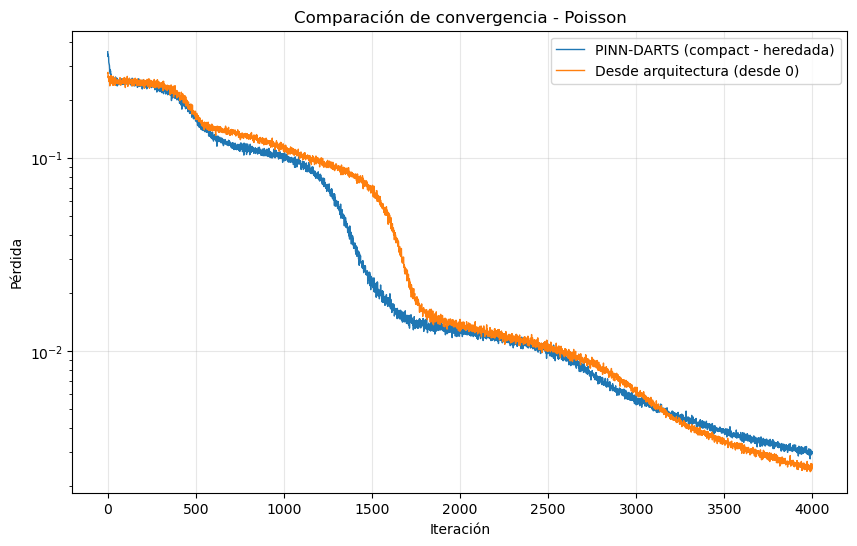


Evaluando modelo compacto (DARTS herencia)...


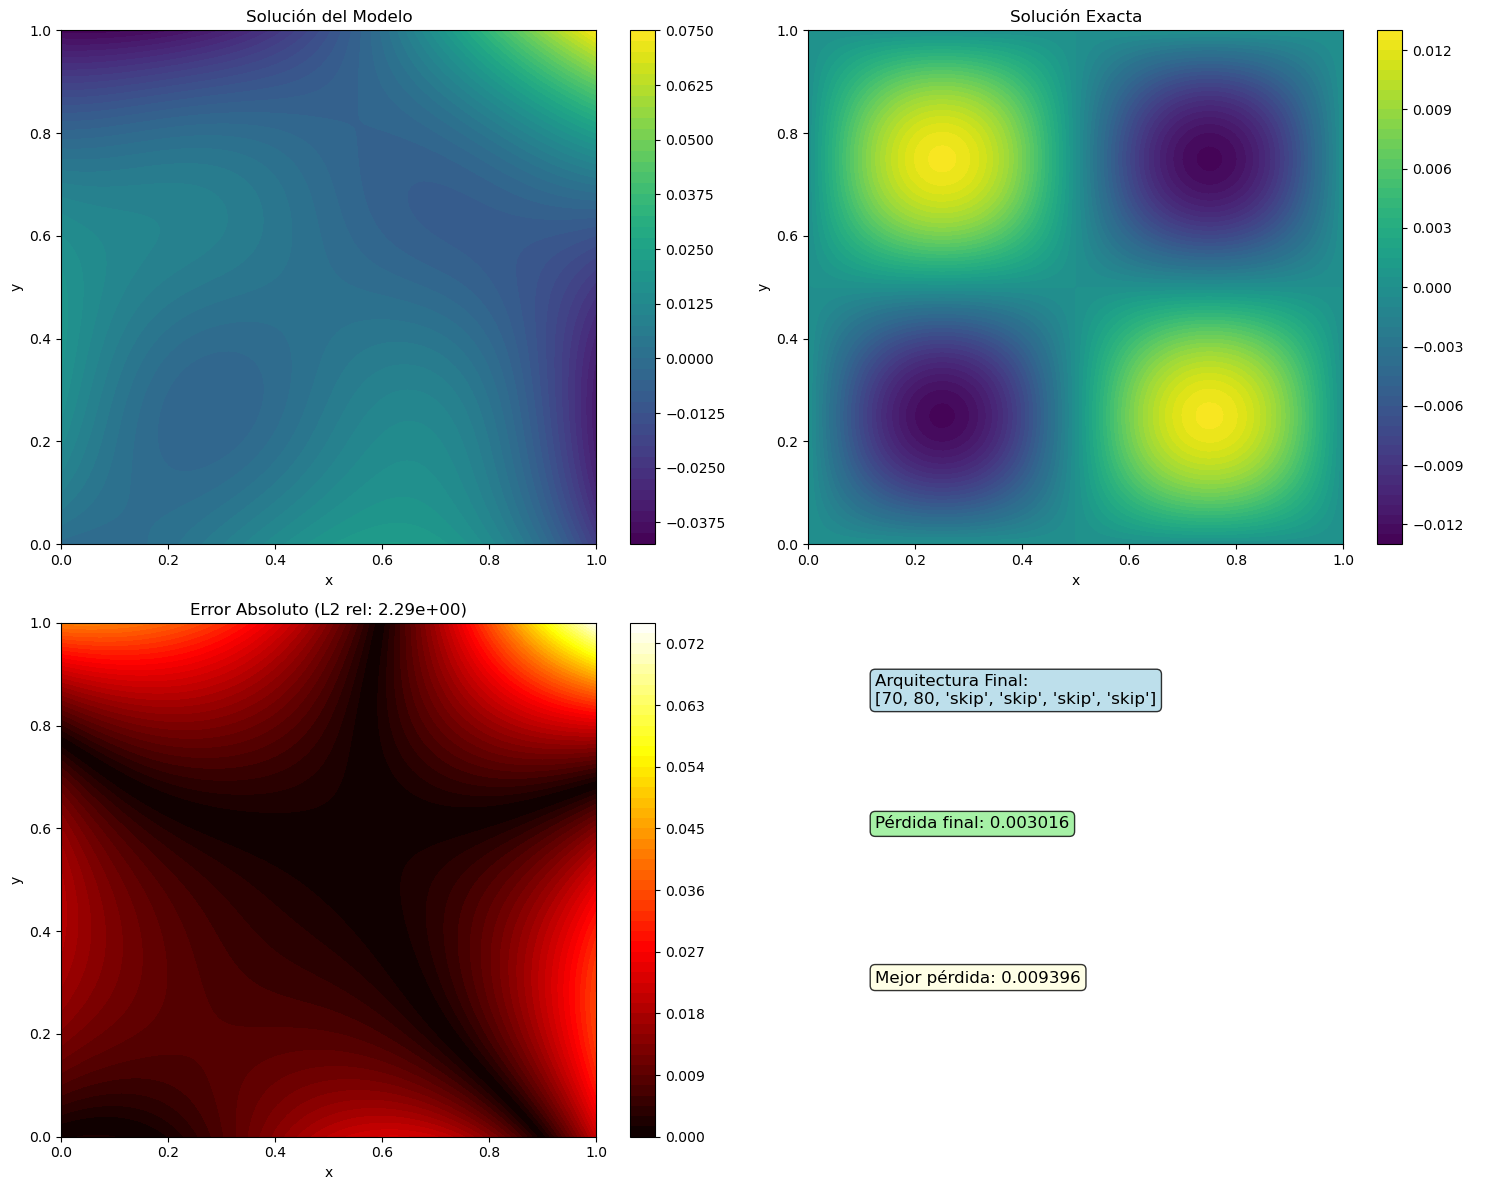


Evaluando modelo desde arquitectura (desde 0)...


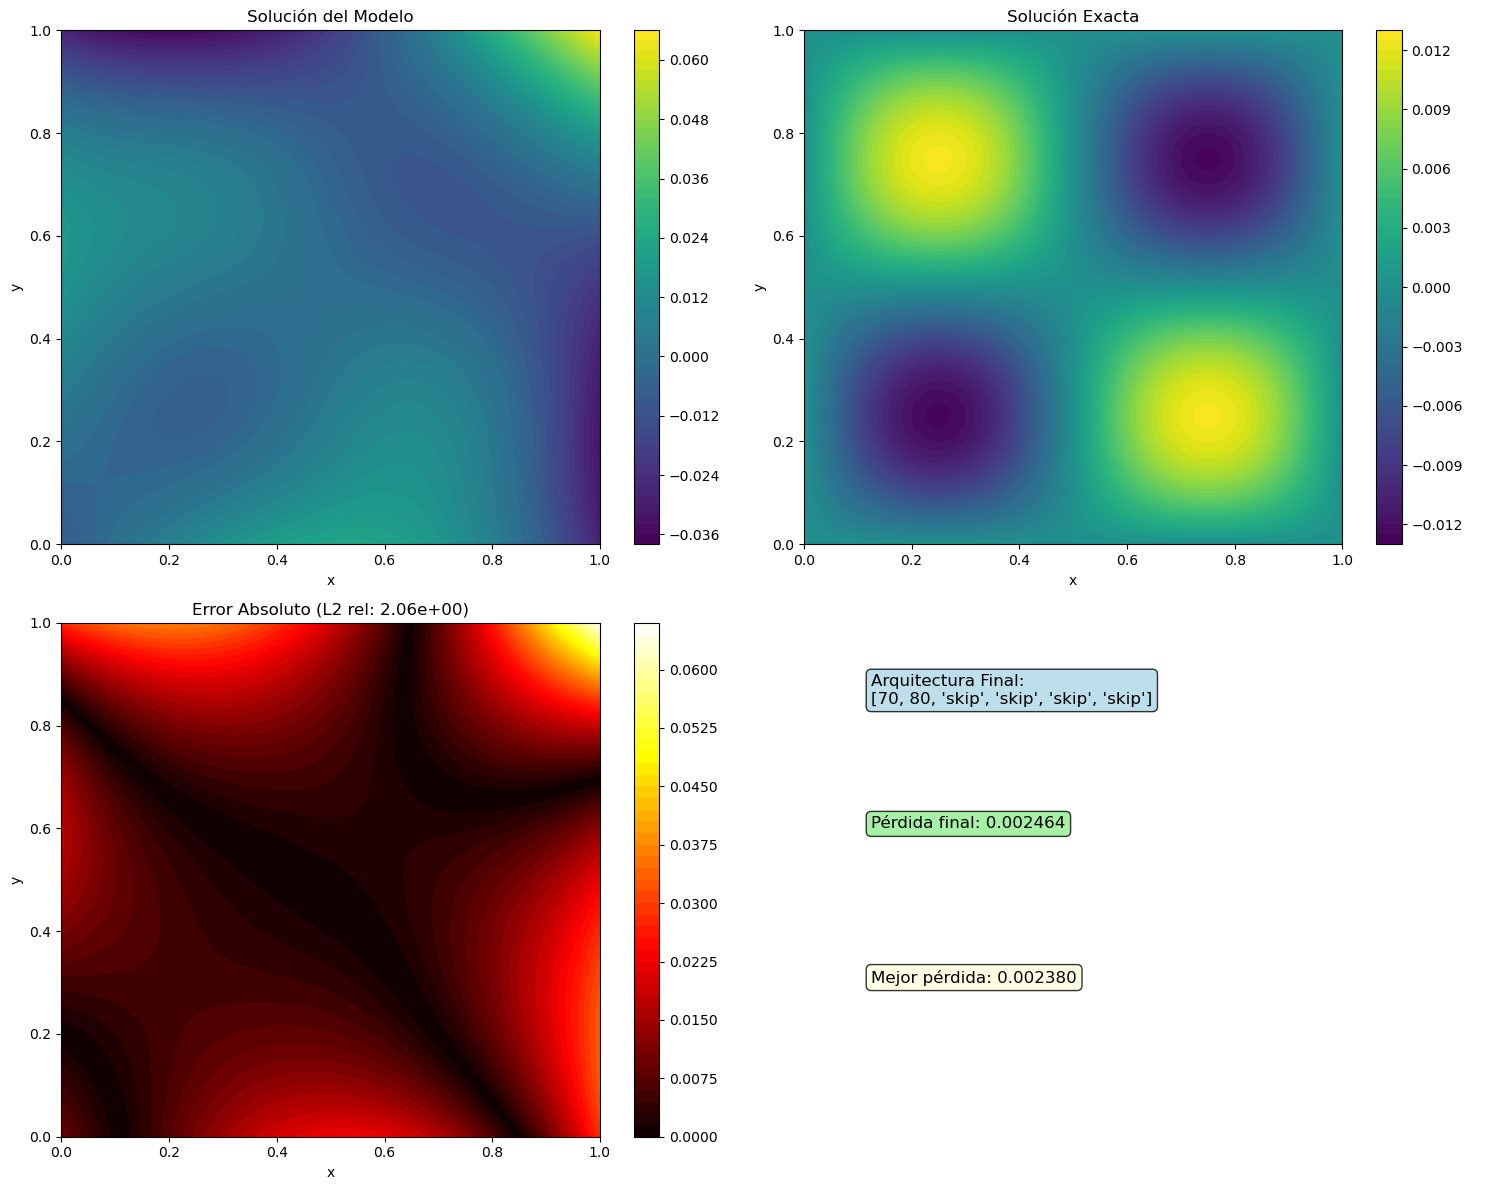


RESUMEN FINAL - ECUACIÓN DE POISSON
Activación usada: tanh
Arquitectura encontrada: [70, 80, 'skip', 'skip', 'skip', 'skip']
Error L2 relativo (DARTS compact): 2.29e+00
Error L2 relativo (Desde arch): 2.06e+00
MSE (DARTS compact): 2.065e-04
MSE (Desde arch): 1.672e-04


In [6]:
def main(activation='tanh'):
    SEED = 3
    set_seed(SEED)

    N_INTERIOR = 2000
    N_BOUNDARY = 500
    RESAMPLE_EVERY = 1

    # ahora se distinguen búsqueda y entrenamiento
    SEARCH_ITERATIONS = 1000   # iters para búsqueda de arquitectura (lr=1e-3 para pesos)
    TRAIN_ITERATIONS = 4000    # iters para entrenar la red compacta y la de desde-0 (lr=1e-4 para pesos)

    LR_WEIGHTS_SEARCH = 1e-3   # lr de pesos durante búsqueda
    LR_WEIGHTS_TRAIN = 1e-4    # lr de pesos durante entrenamiento (compacta y desde-0)
    LR_ALPHA = 1e-4            # lr para alphas (parámetros de arquitectura)

    CLIP_NORM = 5.0
    SILENT = False
    DISABLE_FILE_IO = True
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    print(f"Entrenando PINN-DARTS para la ecuación de Poisson (activación={activation})...")
    darts_res = train_pinn_darts(
        resample_every=RESAMPLE_EVERY,
        n_interior=N_INTERIOR,
        n_boundary=N_BOUNDARY,
        search_iterations=SEARCH_ITERATIONS,
        train_iterations=TRAIN_ITERATIONS,
        switch_criterion='stable',
        stable_iters=100,
        lr_weights_search=LR_WEIGHTS_SEARCH,
        lr_weights_train=LR_WEIGHTS_TRAIN,
        lr_alpha=LR_ALPHA,
        silent=SILENT,
        disable_file_io=DISABLE_FILE_IO,
        clip_norm=CLIP_NORM,
        device=DEVICE,
        activation=activation
    )

    final_model = darts_res['final_model']
    solver = darts_res['solver']
    losses_search_weights = darts_res['losses_search_weights']
    losses_search_alphas = darts_res['losses_search_alphas']
    losses_compact = darts_res['losses_compact']
    best_arch = darts_res['best_architecture'] if darts_res['best_architecture'] is not None else darts_res['arch']
    best_loss_darts = darts_res['best_loss_search']
    final_loss_darts = darts_res['final_loss_compact']
    mse_compact = darts_res['mse_compact']

    print("\nEntrenando red desde arquitectura encontrada (desde 0)...")
    net_from_arch, losses_from0, best_loss_from0, from0_time = train_from_architecture(
        best_arch,
        solver,
        n_interior=N_INTERIOR,
        n_boundary=N_BOUNDARY,
        iterations=TRAIN_ITERATIONS,
        lr_weights=LR_WEIGHTS_TRAIN,
        resample_every=RESAMPLE_EVERY,
        disable_file_io=DISABLE_FILE_IO,
        silent=SILENT,
        clip_norm=CLIP_NORM,
        device=DEVICE,
        activation=activation
    )

    # calcular MSE para la red entrenada desde 0
    mse_from0 = compute_mse_on_grid(net_from_arch, solver, device=DEVICE, grid_n=100)

    # Gráficas de comparación de pérdidas
    plt.figure(figsize=(10,6))
    iters_compact = np.arange(len(losses_compact))
    iters_from0 = np.arange(len(losses_from0))
    plt.plot(iters_compact, losses_compact, label='PINN-DARTS (compact - heredada)', linewidth=1)
    plt.plot(iters_from0, losses_from0, label='Desde arquitectura (desde 0)', linewidth=1)
    plt.xlabel('Iteración')
    plt.ylabel('Pérdida')
    plt.yscale('log')
    plt.title('Comparación de convergencia - Poisson')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    # Evaluaciones y plots detallados
    print("\nEvaluando modelo compacto (DARTS herencia)...")
    fig_darts, l2_darts = evaluate_and_plot(final_model, solver, best_arch, final_loss_darts,
                                           best_loss=best_loss_darts, title_suffix="_DARTS", disable_file_io=DISABLE_FILE_IO)

    print("\nEvaluando modelo desde arquitectura (desde 0)...")
    fig_arch, l2_arch = evaluate_and_plot(net_from_arch, solver, best_arch, losses_from0[-1],
                                         best_loss=best_loss_from0, title_suffix="_FromArch", disable_file_io=DISABLE_FILE_IO)

    print("\n" + "="*60)
    print("RESUMEN FINAL - ECUACIÓN DE POISSON")
    print("="*60)
    print(f"Activación usada: {activation}")
    print(f"Arquitectura encontrada: {best_arch}")
    print(f"Error L2 relativo (DARTS compact): {l2_darts:.2e}")
    print(f"Error L2 relativo (Desde arch): {l2_arch:.2e}")
    print(f"MSE (DARTS compact): {mse_compact:.3e}")
    print(f"MSE (Desde arch): {mse_from0:.3e}")
    print("="*60)

    results = {
        'final_model_compact': final_model,
        'net_from_arch': net_from_arch,
        'solver': solver,
        'losses_search_weights': losses_search_weights,
        'losses_search_alphas': losses_search_alphas,
        'losses_compact': losses_compact,
        'losses_from0': losses_from0,
        'best_architecture': best_arch,
        'best_loss_darts': best_loss_darts,
        'final_loss_compact': final_loss_darts,
        'best_loss_from0': best_loss_from0,
        'mse_compact': mse_compact,
        'mse_from0': mse_from0,
        'l2_rel_compact': l2_darts,
        'l2_rel_from0': l2_arch
    }
    return results

if __name__ == "__main__":
    ACTIVATION = 'tanh'
    results = main(activation=ACTIVATION)

In [25]:
df_poisson = summaries_to_dataframe(seed_summaries, "Poisson")
df_advection = summaries_to_dataframe(advection_seed_summaries, "Advection")

display(df_poisson)
display(df_advection)

,benchmark,seed,architecture,method,initial_loss,final_loss,final_mse,best_loss,threshold_reached,iterations_to_threshold
0,Poisson,0,"[80, 'skip', 60, 50, 'skip', 'skip']",scratch,0.254564,0.000056,4.443669e-07,0.000055,1,3100.0
1,Poisson,0,"[80, 'skip', 60, 50, 'skip', 'skip']",inheritance,0.290899,0.000115,6.293328e-06,0.000115,1,4600.0
2,Poisson,0,"[80, 'skip', 60, 50, 'skip', 'skip']",inheritance_warmup,0.293080,0.000103,4.792092e-06,0.000103,1,4250.0
3,Poisson,1,"[60, 50, 70, 'skip', 50, 'skip']",scratch,0.270861,0.000088,2.079978e-06,0.000088,1,3800.0
4,Poisson,1,"[60, 50, 70, 'skip', 50, 'skip']",inheritance,0.267797,0.000085,1.224430e-06,0.000085,1,3950.0
5,Poisson,1,"[60, 50, 70, 'skip', 50, 'skip']",inheritance_warmup,0.263257,0.000094,2.351294e-06,0.000094,1,4100.0
6,Poisson,2,"[70, 50, 80, 70, 70, 80]",scratch,0.245297,0.000057,1.478494e-06,0.000057,1,3850.0
7,Poisson,2,"[70, 50, 80, 70, 70, 80]",inheritance,9.721571,0.001841,1.029884e-04,0.001841,0,NaN
8,Poisson,2,"[70, 50, 80, 70, 70, 80]",inheritance_warmup,9.684229,0.001990,1.100212e-04,0.001982,0,NaN


,benchmark,seed,architecture,method,initial_loss,final_loss,final_mse,best_loss,threshold_reached,iterations_to_threshold
0,Advection,0,"[75, 75, 'skip', 'skip', 'skip']",scratch,0.790226,0.000042,0.000003,0.000041,1,3900.0
1,Advection,0,"[75, 75, 'skip', 'skip', 'skip']",inheritance,0.170469,0.000022,0.000005,0.000022,1,4250.0
2,Advection,0,"[75, 75, 'skip', 'skip', 'skip']",inheritance_warmup,0.172123,0.000024,0.000005,0.000024,1,4200.0
3,Advection,1,"[100, 100, 'skip', 'skip', 'skip']",scratch,1.192312,0.000031,0.000002,0.000027,1,3200.0
4,Advection,1,"[100, 100, 'skip', 'skip', 'skip']",inheritance,1.563552,0.000027,0.000001,0.000027,1,2650.0
5,Advection,1,"[100, 100, 'skip', 'skip', 'skip']",inheritance_warmup,1.626075,0.000027,0.000001,0.000027,1,2600.0
6,Advection,2,"[25, 'skip', 25, 25, 'skip']",scratch,0.906192,0.000240,0.000022,0.000240,0,NaN
7,Advection,2,"[25, 'skip', 25, 25, 'skip']",inheritance,1.135259,0.000111,0.000009,0.000104,1,4900.0
8,Advection,2,"[25, 'skip', 25, 25, 'skip']",inheritance_warmup,1.126480,0.000122,0.000012,0.000122,0,NaN


In [29]:
def aggregate_for_paper(df):
    # Main aggregates
    grouped = df.groupby(["benchmark", "method"], as_index=False).agg(
        initial_loss_mean=("initial_loss", "mean"),
        initial_loss_std=("initial_loss", "std"),
        final_loss_mean=("final_loss", "mean"),
        final_loss_std=("final_loss", "std"),
        final_mse_mean=("final_mse", "mean"),
        final_mse_std=("final_mse", "std"),
        threshold_reached_sum=("threshold_reached", "sum"),
        n_runs=("threshold_reached", "count"),
    )

    # Threshold statistics only on successful runs
    thr_df = df.dropna(subset=["iterations_to_threshold"]).copy()

    if len(thr_df) > 0:
        thr_stats = thr_df.groupby(["benchmark", "method"], as_index=False).agg(
            iterations_to_threshold_mean=("iterations_to_threshold", "mean"),
            iterations_to_threshold_std=("iterations_to_threshold", "std"),
        )
        grouped = grouped.merge(thr_stats, on=["benchmark", "method"], how="left")
    else:
        grouped["iterations_to_threshold_mean"] = np.nan
        grouped["iterations_to_threshold_std"] = np.nan

    grouped["threshold_success_rate"] = (
        grouped["threshold_reached_sum"].astype(int).astype(str)
        + "/"
        + grouped["n_runs"].astype(int).astype(str)
    )

    return grouped

In [30]:
paper_table = aggregate_for_paper(pd.concat([df_poisson, df_advection], ignore_index=True))
display(paper_table)

,benchmark,method,initial_loss_mean,initial_loss_std,final_loss_mean,final_loss_std,final_mse_mean,final_mse_std,threshold_reached_sum,n_runs,iterations_to_threshold_mean,iterations_to_threshold_std,threshold_success_rate
0,Advection,inheritance,0.956427,0.713552,0.000053,0.000050,0.000005,3.832601e-06,3,3,3933.333333,1157.943580,3/3
1,Advection,inheritance_warmup,0.974893,0.738734,0.000058,0.000055,0.000006,5.553669e-06,2,3,3400.000000,1131.370850,2/3
2,Advection,scratch,0.962910,0.206957,0.000104,0.000118,0.000009,1.115187e-05,2,3,3550.000000,494.974747,2/3
3,Poisson,inheritance,3.426756,5.451482,0.000680,0.001005,0.000037,5.734620e-05,2,3,4275.000000,459.619408,2/3
4,Poisson,inheritance_warmup,3.413522,5.430612,0.000729,0.001092,0.000039,6.147075e-05,2,3,4175.000000,106.066017,2/3
5,Poisson,scratch,0.256907,0.012942,0.000067,0.000019,0.000001,8.272874e-07,3,3,3583.333333,419.324854,3/3


In [31]:
table_poisson = paper_table[paper_table["benchmark"] == "Poisson"].copy()
table_advection = paper_table[paper_table["benchmark"] == "Advection"].copy()

display(table_poisson)
display(table_advection)

,benchmark,method,initial_loss_mean,initial_loss_std,final_loss_mean,final_loss_std,final_mse_mean,final_mse_std,threshold_reached_sum,n_runs,iterations_to_threshold_mean,iterations_to_threshold_std,threshold_success_rate
3,Poisson,inheritance,3.426756,5.451482,0.000680,0.001005,0.000037,5.734620e-05,2,3,4275.000000,459.619408,2/3
4,Poisson,inheritance_warmup,3.413522,5.430612,0.000729,0.001092,0.000039,6.147075e-05,2,3,4175.000000,106.066017,2/3
5,Poisson,scratch,0.256907,0.012942,0.000067,0.000019,0.000001,8.272874e-07,3,3,3583.333333,419.324854,3/3


,benchmark,method,initial_loss_mean,initial_loss_std,final_loss_mean,final_loss_std,final_mse_mean,final_mse_std,threshold_reached_sum,n_runs,iterations_to_threshold_mean,iterations_to_threshold_std,threshold_success_rate
0,Advection,inheritance,0.956427,0.713552,0.000053,0.000050,0.000005,0.000004,3,3,3933.333333,1157.943580,3/3
1,Advection,inheritance_warmup,0.974893,0.738734,0.000058,0.000055,0.000006,0.000006,2,3,3400.000000,1131.370850,2/3
2,Advection,scratch,0.962910,0.206957,0.000104,0.000118,0.000009,0.000011,2,3,3550.000000,494.974747,2/3


In [32]:
def format_mean_std(mean_val, std_val, scientific=True):
    if pd.isna(mean_val):
        return "N/A"
    if pd.isna(std_val):
        std_val = 0.0
    if scientific:
        return f"{mean_val:.2e} ± {std_val:.2e}"
    return f"{mean_val:.4f} ± {std_val:.4f}"


def make_pretty_paper_table(table_df):
    pretty = pd.DataFrame()
    pretty["Method"] = table_df["method"].map({
        "scratch": "Scratch",
        "inheritance": "Inheritance",
        "inheritance_warmup": "Inheritance + Warm-up"
    })
    pretty["Initial loss"] = [
        format_mean_std(m, s) for m, s in zip(table_df["initial_loss_mean"], table_df["initial_loss_std"])
    ]
    pretty["Final loss"] = [
        format_mean_std(m, s) for m, s in zip(table_df["final_loss_mean"], table_df["final_loss_std"])
    ]
    pretty["Final MSE"] = [
        format_mean_std(m, s) for m, s in zip(table_df["final_mse_mean"], table_df["final_mse_std"])
    ]
    pretty["Threshold reached"] = table_df["threshold_success_rate"]
    pretty["Iter. to threshold"] = [
        "N/A" if pd.isna(m) else f"{m:.1f} ± {s:.1f}"
        for m, s in zip(table_df["iterations_to_threshold_mean"], table_df["iterations_to_threshold_std"])
    ]
    return pretty

In [33]:
pretty_poisson = make_pretty_paper_table(table_poisson)
pretty_advection = make_pretty_paper_table(table_advection)

display(pretty_poisson)
display(pretty_advection)

,Method,Initial loss,Final loss,Final MSE,Threshold reached,Iter. to threshold
3,Inheritance,3.43e+00 ± 5.45e+00,6.80e-04 ± 1.01e-03,3.68e-05 ± 5.73e-05,2/3,4275.0 ± 459.6
4,Inheritance + Warm-up,3.41e+00 ± 5.43e+00,7.29e-04 ± 1.09e-03,3.91e-05 ± 6.15e-05,2/3,4175.0 ± 106.1
5,Scratch,2.57e-01 ± 1.29e-02,6.71e-05 ± 1.85e-05,1.33e-06 ± 8.27e-07,3/3,3583.3 ± 419.3


,Method,Initial loss,Final loss,Final MSE,Threshold reached,Iter. to threshold
0,Inheritance,9.56e-01 ± 7.14e-01,5.32e-05 ± 4.97e-05,5.11e-06 ± 3.83e-06,3/3,3933.3 ± 1157.9
1,Inheritance + Warm-up,9.75e-01 ± 7.39e-01,5.78e-05 ± 5.54e-05,5.92e-06 ± 5.55e-06,2/3,3400.0 ± 1131.4
2,Scratch,9.63e-01 ± 2.07e-01,1.04e-04 ± 1.18e-04,8.92e-06 ± 1.12e-05,2/3,3550.0 ± 495.0


In [34]:
def dataframe_to_latex_table(df, caption, label):
    latex = df.to_latex(index=False, escape=False)
    wrapped = f"""\\begin{{table}}[t]
\\centering
\\caption{{{caption}}}
\\label{{{label}}}
{latex}
\\end{{table}}"""
    return wrapped


latex_poisson = dataframe_to_latex_table(
    pretty_poisson,
    caption="Poisson benchmark results over 3 seeds. Values are reported as mean $\\pm$ standard deviation.",
    label="tab:poisson_results"
)

latex_advection = dataframe_to_latex_table(
    pretty_advection,
    caption="Advection benchmark results over 3 seeds. Values are reported as mean $\\pm$ standard deviation.",
    label="tab:advection_results"
)

print(latex_poisson)
print()
print(latex_advection)

\begin{table}[t]
\centering
\caption{Poisson benchmark results over 3 seeds. Values are reported as mean $\pm$ standard deviation.}
\label{tab:poisson_results}
\begin{tabular}{llllll}
\toprule
Method & Initial loss & Final loss & Final MSE & Threshold reached & Iter. to threshold \\
\midrule
Inheritance & 3.43e+00 ± 5.45e+00 & 6.80e-04 ± 1.01e-03 & 3.68e-05 ± 5.73e-05 & 2/3 & 4275.0 ± 459.6 \\
Inheritance + Warm-up & 3.41e+00 ± 5.43e+00 & 7.29e-04 ± 1.09e-03 & 3.91e-05 ± 6.15e-05 & 2/3 & 4175.0 ± 106.1 \\
Scratch & 2.57e-01 ± 1.29e-02 & 6.71e-05 ± 1.85e-05 & 1.33e-06 ± 8.27e-07 & 3/3 & 3583.3 ± 419.3 \\
\bottomrule
\end{tabular}

\end{table}

\begin{table}[t]
\centering
\caption{Advection benchmark results over 3 seeds. Values are reported as mean $\pm$ standard deviation.}
\label{tab:advection_results}
\begin{tabular}{llllll}
\toprule
Method & Initial loss & Final loss & Final MSE & Threshold reached & Iter. to threshold \\
\midrule
Inheritance & 9.56e-01 ± 7.14e-01 & 5.32e-05 ± 4.97e

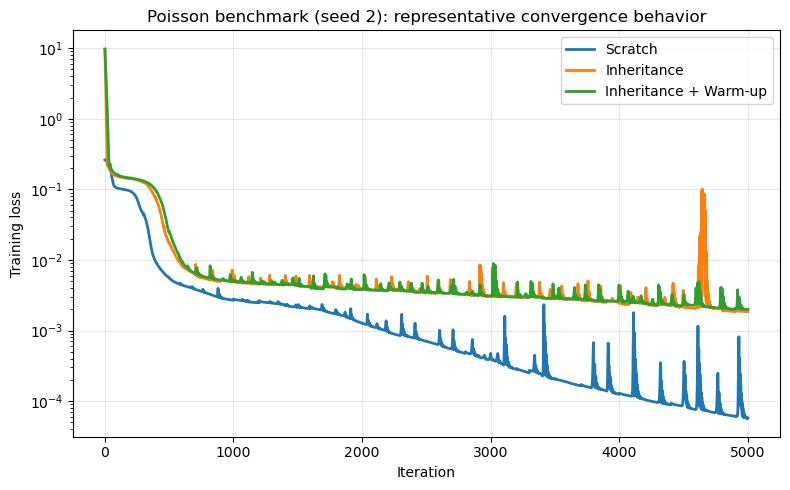

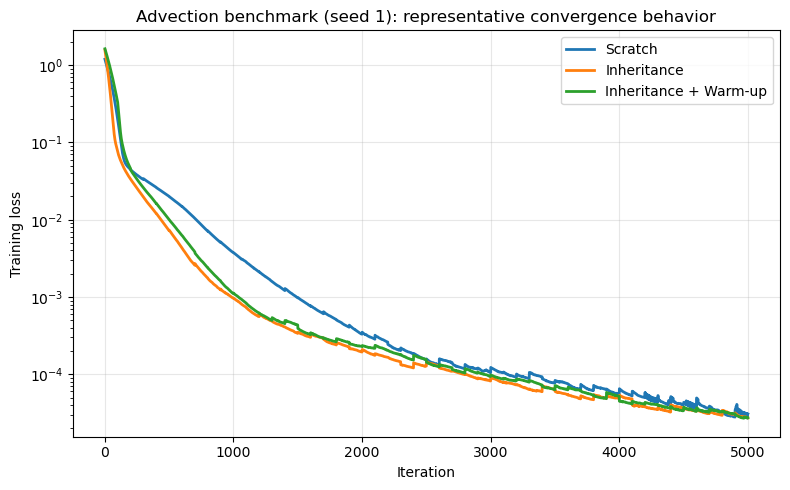

In [35]:
import matplotlib.pyplot as plt

def plot_method_loss_curves(results_dict, title="", logy=True):
    plt.figure(figsize=(8, 5))

    method_labels = {
        "scratch": "Scratch",
        "inheritance": "Inheritance",
        "inheritance_warmup": "Inheritance + Warm-up"
    }

    for key in ["scratch", "inheritance", "inheritance_warmup"]:
        history = results_dict[key]["history"]
        losses = history["losses"]
        plt.plot(np.arange(1, len(losses) + 1), losses, label=method_labels[key], linewidth=2)

    plt.xlabel("Iteration")
    plt.ylabel("Training loss")
    plt.title(title)
    if logy:
        plt.yscale("log")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_method_loss_curves(
    all_results[2],
    title="Poisson benchmark (seed 2): representative convergence behavior",
    logy=True
)

plot_method_loss_curves(
    advection_all_results[1],
    title="Advection benchmark (seed 1): representative convergence behavior",
    logy=True
)

In [36]:
def save_method_loss_curves(results_dict, filepath, title="", logy=True):
    plt.figure(figsize=(8, 5))

    method_labels = {
        "scratch": "Scratch",
        "inheritance": "Inheritance",
        "inheritance_warmup": "Inheritance + Warm-up"
    }

    for key in ["scratch", "inheritance", "inheritance_warmup"]:
        history = results_dict[key]["history"]
        losses = history["losses"]
        plt.plot(np.arange(1, len(losses) + 1), losses, label=method_labels[key], linewidth=2)

    plt.xlabel("Iteration")
    plt.ylabel("Training loss")
    plt.title(title)
    if logy:
        plt.yscale("log")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(filepath, dpi=300, bbox_inches="tight")
    plt.close()


save_method_loss_curves(
    all_results[2],
    "poisson_seed2_convergence.png",
    title="Poisson benchmark (seed 2): representative convergence behavior",
    logy=True
)

save_method_loss_curves(
    advection_all_results[1],
    "advection_seed1_convergence.png",
    title="Advection benchmark (seed 1): representative convergence behavior",
    logy=True
)

